# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, EarlyStopperRL, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, compute_weight_change_from_snapshots, plot_sa_encoder_changes_across_tasks)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, contrastive_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


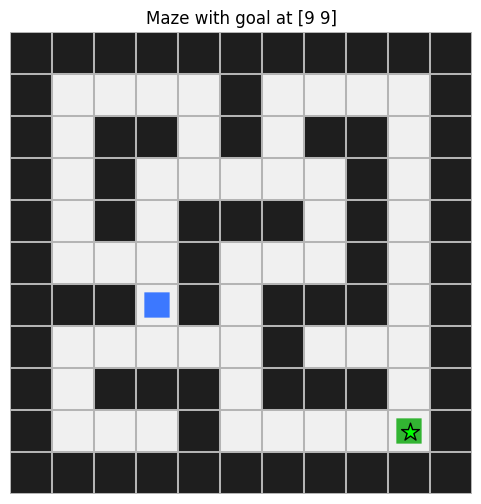

Number of free cells: 52
First few free cells: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 6), (1, 7), (1, 8), (1, 9), (2, 1), (2, 4)]


In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

# ===== Experiment helpers: free cells, random goals, summaries =====

def get_free_cells(maze_layout):
    free_cells = []
    for r, row in enumerate(maze_layout):
        for c, val in enumerate(row):
            if val == 0:
                free_cells.append((r, c))
    return free_cells

FREE_CELLS = get_free_cells(MAZE_LAYOUT)
print(f"Number of free cells: {len(FREE_CELLS)}")
print("First few free cells:", FREE_CELLS[:10])

def sample_goals(num_goals, rng, exclude=None):
    exclude = set() if exclude is None else set(exclude)
    candidates = [g for g in FREE_CELLS if g not in exclude]
    assert num_goals <= len(candidates), "Requested more goals than available free cells."
    idx = rng.choice(len(candidates), size=num_goals, replace=False)
    return [candidates[i] for i in idx]

def init_goal_results_dict(goals):
    return {
        goal: {
            "eval_returns": [],
            "min_steps": [],
            "min_time": [],
            "task_embeddings": [],
            "sa_embeddings": [],
            "sa_fixed_probe_embeddings": [],
            "sa_batches_final": [],
            "sa_weight_change": [],
            "goal_weight_change": [],
        }
        for goal in goals
    }

def summarise_across_seeds(results_dict):
    summary = {}
    for goal, data in results_dict.items():
        steps_vals = np.array(
            [np.nan if x is None else x for x in data.get("min_steps", [])],
            dtype=float
        )
        time_vals = np.array(
            [np.nan if x is None else x for x in data.get("min_time", [])],
            dtype=float
        )
        summary[goal] = {
            "steps_mean": None if len(steps_vals) == 0 or np.all(np.isnan(steps_vals)) else float(np.nanmean(steps_vals)),
            "steps_std":  None if len(steps_vals) == 0 or np.all(np.isnan(steps_vals)) else float(np.nanstd(steps_vals)),
            "time_mean":  None if len(time_vals) == 0 or np.all(np.isnan(time_vals)) else float(np.nanmean(time_vals)),
            "time_std":   None if len(time_vals) == 0 or np.all(np.isnan(time_vals)) else float(np.nanstd(time_vals)),
            "num_valid_steps": int(np.sum(~np.isnan(steps_vals))) if len(steps_vals) else 0,
            "num_valid_time":  int(np.sum(~np.isnan(time_vals))) if len(time_vals) else 0,
        }
    return summary

def print_summary_table(summary_dict, title="Summary"):
    print(f"\n===== {title} =====")
    for goal, stats in summary_dict.items():
        print(
            f"Goal {goal}: "
            f"steps mean={stats['steps_mean']}, std={stats['steps_std']}, valid={stats['num_valid_steps']} | "
            f"time mean={stats['time_mean']}, std={stats['time_std']}, valid={stats['num_valid_time']}"
        )

def set_trainable_parts(model, freeze_sa=False, freeze_goal=False):
    for name, p in model.named_parameters():
        p.requires_grad_(True)
        if freeze_sa and name.startswith("sa_encoder"):
            p.requires_grad_(False)
        if freeze_goal and name.startswith("goal_encoder"):
            p.requires_grad_(False)
    return [p for p in model.parameters() if p.requires_grad]

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FactorisedDQN_QNetwork(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int,
        hidden_dim: int = 128,
        rep_dim: int = 64,
        q_hidden_dim: int = 128,
        normalize_embeddings: bool = True,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions
        self.goal_dim = goal_dim
        self.hidden_dim = hidden_dim
        self.rep_dim = rep_dim
        self.q_hidden_dim = q_hidden_dim
        self.normalize_embeddings = normalize_embeddings

        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + num_actions, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.q_head = nn.Sequential(
            nn.Linear(2 * rep_dim, q_hidden_dim),
            nn.ReLU(),
            nn.Linear(q_hidden_dim, 1),
        )

    def encode_state_action(self, obs: torch.Tensor, act_onehot: torch.Tensor) -> torch.Tensor:
        x = torch.cat([obs, act_onehot], dim=-1)
        z = self.sa_encoder(x)
        if self.normalize_embeddings:
            z = F.normalize(z, dim=-1)
        return z

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        z = self.goal_encoder(goal)
        if self.normalize_embeddings:
            z = F.normalize(z, dim=-1)
        return z

    def q_from_embeddings(self, phi: torch.Tensor, psi: torch.Tensor) -> torch.Tensor:
        x = torch.cat([phi, psi], dim=-1)
        return self.q_head(x)

    def q_values_from_state_goal(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        """
        obs:  [B, obs_dim]
        goal: [B, goal_dim]
        returns: [B, num_actions]
        """
        B = obs.shape[0]
        device = obs.device

        psi = self.encode_goal(goal)  # [B, rep_dim]

        act_eye = torch.eye(self.num_actions, device=device).unsqueeze(0).expand(B, -1, -1)
        obs_rep = obs.unsqueeze(1).expand(-1, self.num_actions, -1)

        obs_flat = obs_rep.reshape(B * self.num_actions, self.obs_dim)
        act_flat = act_eye.reshape(B * self.num_actions, self.num_actions)
        phi_flat = self.encode_state_action(obs_flat, act_flat)  # [B*A, rep_dim]

        psi_rep = psi.unsqueeze(1).expand(-1, self.num_actions, -1).reshape(B * self.num_actions, self.rep_dim)

        q_flat = self.q_from_embeddings(phi_flat, psi_rep)  # [B*A, 1]
        q_vals = q_flat.view(B, self.num_actions)
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        return self.q_values_from_state_goal(obs, goal)

    def q_val_for_argmax_action_from_embedding(
        self,
        obs: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q-values for all actions using a provided task embedding.

        obs: [B, obs_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        returns: [B, A]
        """
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                             # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)  # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)          # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)       # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim) # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat) # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)              # [B, A, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(B, -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)         # [B, A, D]
        q_vals = (phi_sa * psi_rep).sum(dim=-1)               # [B, A]
        return q_vals

class NextStateEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 128, rep_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, next_obs: torch.Tensor) -> torch.Tensor:
        z = self.net(next_obs)
        z = F.normalize(z, dim=-1)
        return z

In [4]:
class EWCState:
    def __init__(self):
        self.ref_params_sa = None
        self.fisher_sa = None
        self.ref_params_ns = None
        self.fisher_ns = None

def compute_ewc_fisher_for_task(
    q_network,
    next_state_encoder,
    replay_buffer,
    goal,
    num_actions,
    device,
    num_batches: int = 50,
    batch_size: int = 256,
    gamma: float = 0.99,
    temperature: float = 0.05,
    contrastive_reg_coef: float = 0.0,
    sigreg_coef: float = 0.0,
    dyn_coef: float = 1.0,
    fisher_on: str = "dynamics",  # "dynamics" or "td"
):
    q_network.eval()
    next_state_encoder.eval()

    fisher_sa = {
        name: torch.zeros_like(p, device=device)
        for name, p in q_network.sa_encoder.named_parameters()
    }
    fisher_ns = {
        name: torch.zeros_like(p, device=device)
        for name, p in next_state_encoder.named_parameters()
    }

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    for _ in range(num_batches):
        batch = replay_buffer.sample(batch_size)

        obs_t = batch.obs
        act_t = batch.actions.long()
        rew_t = batch.rewards
        next_obs_t = batch.next_obs
        term_t = batch.terminated.float()
        trunc_t = batch.truncated.float()

        done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
        if done_t.ndim == 1:
            done_t = done_t.unsqueeze(-1)
        if rew_t.ndim == 1:
            rew_t = rew_t.unsqueeze(-1)

        B = obs_t.shape[0]
        goal_batch = goal_t_single.expand(B, -1)

        act_onehot = F.one_hot(
            act_t.squeeze(-1),
            num_classes=num_actions
        ).float()

        q_network.zero_grad(set_to_none=True)
        next_state_encoder.zero_grad(set_to_none=True)

        if fisher_on == "dynamics":
            z_sa = q_network.encode_state_action(obs_t, act_onehot)
            z_s_prime = next_state_encoder(next_obs_t)

            logits = z_sa @ z_s_prime.T
            loss = contrastive_loss(
                logits,
                temperature=temperature,
                reg_coef=contrastive_reg_coef,
            )

            if sigreg_coef > 0.0:
                loss = dyn_coef * loss + sigreg_coef * sigreg_loss(z_sa)
            else:
                loss = dyn_coef * loss

        elif fisher_on == "td":
            phi_td = q_network.encode_state_action(obs_t, act_onehot)
            psi_g = q_network.encode_goal(goal_batch)
            current_q = q_network.q_from_embeddings(phi_td, psi_g)

            with torch.no_grad():
                next_q_vals = q_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                next_q = next_q_vals.max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - done_t) * next_q

            loss = F.mse_loss(current_q, target)

        else:
            raise ValueError(f"Unknown fisher_on={fisher_on}")

        loss.backward()

        for name, p in q_network.sa_encoder.named_parameters():
            if p.grad is not None:
                fisher_sa[name] += p.grad.detach().pow(2)

        for name, p in next_state_encoder.named_parameters():
            if p.grad is not None:
                fisher_ns[name] += p.grad.detach().pow(2)

    for name in fisher_sa:
        fisher_sa[name] /= float(num_batches)
    for name in fisher_ns:
        fisher_ns[name] /= float(num_batches)

    ref_params_sa = {
        name: p.detach().clone()
        for name, p in q_network.sa_encoder.named_parameters()
    }
    ref_params_ns = {
        name: p.detach().clone()
        for name, p in next_state_encoder.named_parameters()
    }

    q_network.train()
    next_state_encoder.train()

    return ref_params_sa, fisher_sa, ref_params_ns, fisher_ns

In [5]:
def dqn_train_mlp_head_online(
    seed: int = 42,
    q_network=None,
    q_target_network=None,
    env=None,
    buffer_capacity=None,
    obs_dim=None,
    device=None,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
    goal=None,
    td_steps=1,
    make_env=None,
    epsilon_reduction=False,
    eps_start_transfer=0.5,
    eps_end_transfer=0.05,
    eps_decay_steps_transfer=20000,
    lr_sa=1e-3,
    lr_ns=1e-3,
    lr_td=1e-3,
    next_state_encoder=None,
    temperature=0.05,
    contrastive_reg_coef=0.0,
    sigreg_coef=0.0,
    dyn_coef=1.0,
    freeze_sa_encoder=False,
    ewc_state=None,
    ewc_lambda_sa=0.0,
    ewc_lambda_ns=0.0,
    early_stop_reward=0.99,
    enable_early_stop=True,
    eval_every=1000,
    eval_episodes=16,
    es_ma_window=5,
    es_plateau_patience=8,
    es_min_improvement=0.01,
    es_max_return_var=0.05,
    es_max_epsilon_for_stop=0.30,
    es_min_decay_progress=0.60,

):
    if q_network is None:
        raise ValueError("q_network must be provided")
    if q_target_network is None:
        raise ValueError("q_target_network must be provided")
    if env is None:
        raise ValueError("env must be provided")
    if buffer_capacity is None:
        raise ValueError("buffer_capacity must be provided")
    if goal is None:
        raise ValueError("goal must be provided")
    if make_env is None:
        raise ValueError("make_env must be provided")

    if device is None:
        device = next(q_network.parameters()).device

    if obs_dim is None:
        obs_dim = int(env.observation_space.shape[0])

    set_seed(seed)

    num_actions = env.action_space.n

    if not freeze_sa_encoder:
        if next_state_encoder is None:
            raise ValueError("next_state_encoder must be provided when freeze_sa_encoder=False")
        opt_dyn = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr_sa},
            {"params": next_state_encoder.parameters(), "lr": lr_ns},
        ])
    else:
        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(False)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(False)
        opt_dyn = None

    opt_td = optim.Adam([
        {"params": q_network.goal_encoder.parameters(), "lr": lr_td},
        {"params": q_network.q_head.parameters(), "lr": lr_td},
    ])

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None

    active_decay_steps = eps_decay_steps_transfer if epsilon_reduction else eps_decay_steps
    min_steps_before_stop = int(es_min_decay_progress * active_decay_steps)

    early_stopper = EarlyStopperRL(
        target_reward=early_stop_reward,
        ma_window=es_ma_window,
        plateau_patience=es_plateau_patience,
        min_improvement=es_min_improvement,
        max_return_var=es_max_return_var,
        min_steps_before_stop=min_steps_before_stop,
        max_epsilon_for_stop=es_max_epsilon_for_stop,
    )

    contrastive_loss_val = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    dyn_total_loss = torch.tensor(0.0, device=device)
    td_loss = torch.tensor(0.0, device=device)
    ewc_sa_loss_val = torch.tensor(0.0, device=device)
    ewc_ns_loss_val = torch.tensor(0.0, device=device)
    all_logits = None

    q_network.train()
    q_target_network.train()
    if next_state_encoder is not None:
        next_state_encoder.train()

    while global_step < total_steps:
        if epsilon_reduction:
            frac = min(1.0, global_step / eps_decay_steps_transfer)
            eps = eps_start_transfer + frac * (eps_end_transfer - eps_start_transfer)
        else:
            frac = min(1.0, global_step / eps_decay_steps)
            eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t_single = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t_single, goal_t_single)
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        buffer.add_transition(obs, action, rew, next_obs, done)
        obs = next_obs
        global_step += 1

        if done:
            obs, _ = env.reset()

        if len(buffer) >= warmup_steps:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated.float()
            trunc_t = batch.truncated.float()

            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
            if done_t.ndim == 1:
                done_t = done_t.unsqueeze(-1)
            if rew_t.ndim == 1:
                rew_t = rew_t.unsqueeze(-1)

            B = obs_t.shape[0]
            goal_batch = goal_t_single.expand(B, -1)

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()

            # --------------------------------------------
            # 1) DYNAMICS UPDATE (task 1 only)
            # --------------------------------------------
            if not freeze_sa_encoder:
                z_sa = q_network.encode_state_action(obs_t, act_onehot)
                z_s_prime = next_state_encoder(next_obs_t)

                all_logits = z_sa @ z_s_prime.T

                contrastive_loss_val = contrastive_loss(
                    all_logits,
                    temperature=temperature,
                    reg_coef=contrastive_reg_coef,
                )

                if sigreg_coef > 0.0:
                    sigreg_loss_val = sigreg_loss(z_sa)
                else:
                    sigreg_loss_val = torch.tensor(0.0, device=device)

                dyn_total_loss = dyn_coef * contrastive_loss_val + sigreg_coef * sigreg_loss_val

                if ewc_state is not None:
                    if (
                        ewc_lambda_sa > 0.0
                        and ewc_state.ref_params_sa is not None
                        and ewc_state.fisher_sa is not None
                    ):
                        ewc_sa_loss_val = ewc_regulariser_loss(
                            q_network.sa_encoder,
                            ewc_state.ref_params_sa,
                            ewc_state.fisher_sa,
                        )
                        dyn_total_loss = dyn_total_loss + ewc_lambda_sa * ewc_sa_loss_val

                    if (
                        ewc_lambda_ns > 0.0
                        and ewc_state.ref_params_ns is not None
                        and ewc_state.fisher_ns is not None
                    ):
                        ewc_ns_loss_val = ewc_regulariser_loss(
                            next_state_encoder,
                            ewc_state.ref_params_ns,
                            ewc_state.fisher_ns,
                        )
                        dyn_total_loss = dyn_total_loss + ewc_lambda_ns * ewc_ns_loss_val

                opt_dyn.zero_grad(set_to_none=True)
                dyn_total_loss.backward()
                nn.utils.clip_grad_norm_(q_network.sa_encoder.parameters(), 10.0)
                nn.utils.clip_grad_norm_(next_state_encoder.parameters(), 10.0)
                opt_dyn.step()
            else:
                contrastive_loss_val = torch.tensor(0.0, device=device)
                sigreg_loss_val = torch.tensor(0.0, device=device)
                dyn_total_loss = torch.tensor(0.0, device=device)
                ewc_sa_loss_val = torch.tensor(0.0, device=device)
                ewc_ns_loss_val = torch.tensor(0.0, device=device)


            # --------------------------------------------
            # 2) TD UPDATE
            # --------------------------------------------
            if global_step % train_freq == 0:

                with torch.no_grad():
                    phi_td = q_network.encode_state_action(obs_t, act_onehot)

                psi_g = q_network.encode_goal(goal_batch)
                current_q = q_network.q_from_embeddings(phi_td, psi_g)

                with torch.no_grad():
                    next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                    next_q = next_q_vals.max(dim=-1, keepdim=True).values
                    gamma_final = gamma ** td_steps
                    target = rew_t + gamma_final * (1.0 - done_t) * next_q

                td_loss = F.mse_loss(current_q, target)

                opt_td.zero_grad(set_to_none=True)
                td_loss.backward()
                nn.utils.clip_grad_norm_(q_network.goal_encoder.parameters(), 10.0)
                nn.utils.clip_grad_norm_(q_network.q_head.parameters(), 10.0)
                opt_td.step()

                # --------------------------------------------
                # 3) TARGET UPDATE
                # --------------------------------------------
                with torch.no_grad():
                    for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                        p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % eval_every == 0:
            eval_env = make_env(goal)
            goal_eval_t = torch.tensor(
                np.array(goal, dtype=np.float32),
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len, per_ep_returns = evaluate_policy(
                eval_env,
                eval_policy,
                episodes=eval_episodes,
                return_per_episode=True,
            )

            eval_time = time.perf_counter() - start_time
            eval_returns_time.append((eval_time, mean_ret))
            eval_returns.append((global_step, mean_ret))

            should_stop, stop_info = early_stopper.update(
                step=global_step,
                mean_return=mean_ret,
                episode_returns=per_ep_returns,
                epsilon=eps,
            )

            if all_logits is not None:
                with torch.no_grad():
                    diag_logits = all_logits.diag().mean().item()
                    offdiag_logits = (
                        (all_logits.sum() - all_logits.diag().sum()) /
                        (all_logits.numel() - all_logits.shape[0])
                    ).item()
            else:
                diag_logits = 0.0
                offdiag_logits = 0.0

            print(
                f"[DQN-MLP-head] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f} "
                f"| eval_var={stop_info['return_var']:.4f} "
                f"| ma={stop_info['current_ma']:.3f} "
                f"| best_ma={stop_info['best_ma']:.3f} "
                f"| plateau={stop_info['plateau_streak']} "
                f"| TD={td_loss.item():.4f} "
                f"| Contrastive={contrastive_loss_val.item():.4f} "
                f"| DynTotal={dyn_total_loss.item():.4f} "
                f"| diag={diag_logits:.4f} | offdiag={offdiag_logits:.4f} "
                f"| SigReg={sigreg_loss_val.item():.4f} "
                f"| freeze_sa={freeze_sa_encoder} "
                f"| EWC_SA={ewc_sa_loss_val.item():.10f} "
                f"| EWC_NS={ewc_ns_loss_val.item():.10f}"
            )

            if enable_early_stop and should_stop:
                min_steps = global_step
                min_time = time.perf_counter() - start_time
                print(
                    f"[Early stop] step={global_step} | "
                    f"mean_ret={mean_ret:.3f} | "
                    f"ma={stop_info['current_ma']:.3f} | "
                    f"best_ma={stop_info['best_ma']:.3f} | "
                    f"var={stop_info['return_var']:.4f} | "
                    f"plateau_streak={stop_info['plateau_streak']} | "
                    f"eps={eps:.3f}"
                )
                eval_env.close()
                break

            eval_env.close()

    min_steps = global_step
    min_time = time.perf_counter() - start_time

    goal_tensor = torch.tensor(
        np.array(goal, dtype=np.float32),
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        psi_z = q_network.encode_goal(goal_tensor)
        task_embedding = psi_z.squeeze(0).cpu().numpy()

    obs_probe_np = np.array([5.0, 5.0], dtype=np.float32)

    base_env = env.unwrapped if hasattr(env, "unwrapped") else env
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])
    act_probe_idx = env_action_names.index("Up")

    sa_embedding_mean = extract_mean_sa_embedding(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=256,
        device=device,
        as_numpy=True,
    )

    sa_embedding_fixed = extract_fixed_probe_sa_embedding(
        q_network=q_network,
        obs_probe=obs_probe_np,
        act_probe_idx=act_probe_idx,
        num_actions=num_actions,
        device=device,
        as_numpy=True,
    )

    sa_batch_final = extract_sa_batch_for_isotropy(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=1024,
        device=device,
        as_numpy=True,
    )

    env.close()
    return (
        q_network,
        q_target_network,
        next_state_encoder,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds

Sampled GOALS: [(6, 5), (5, 3), (3, 3), (3, 6), (7, 9)]

SEED 42


----- seed 42, goal (6, 5) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-9.306 | eval_len=100.0 | eval_var=5.7806 | ma=-9.306 | best_ma=-9.306 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-8.094 | eval_len=100.0 | eval_var=15.1268 | ma=-8.700 | best_ma=-8.700 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-8.681 | eval_len=100.0 | eval_var=10.7740 | ma=-8.694 | best_ma=-8.700 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-M

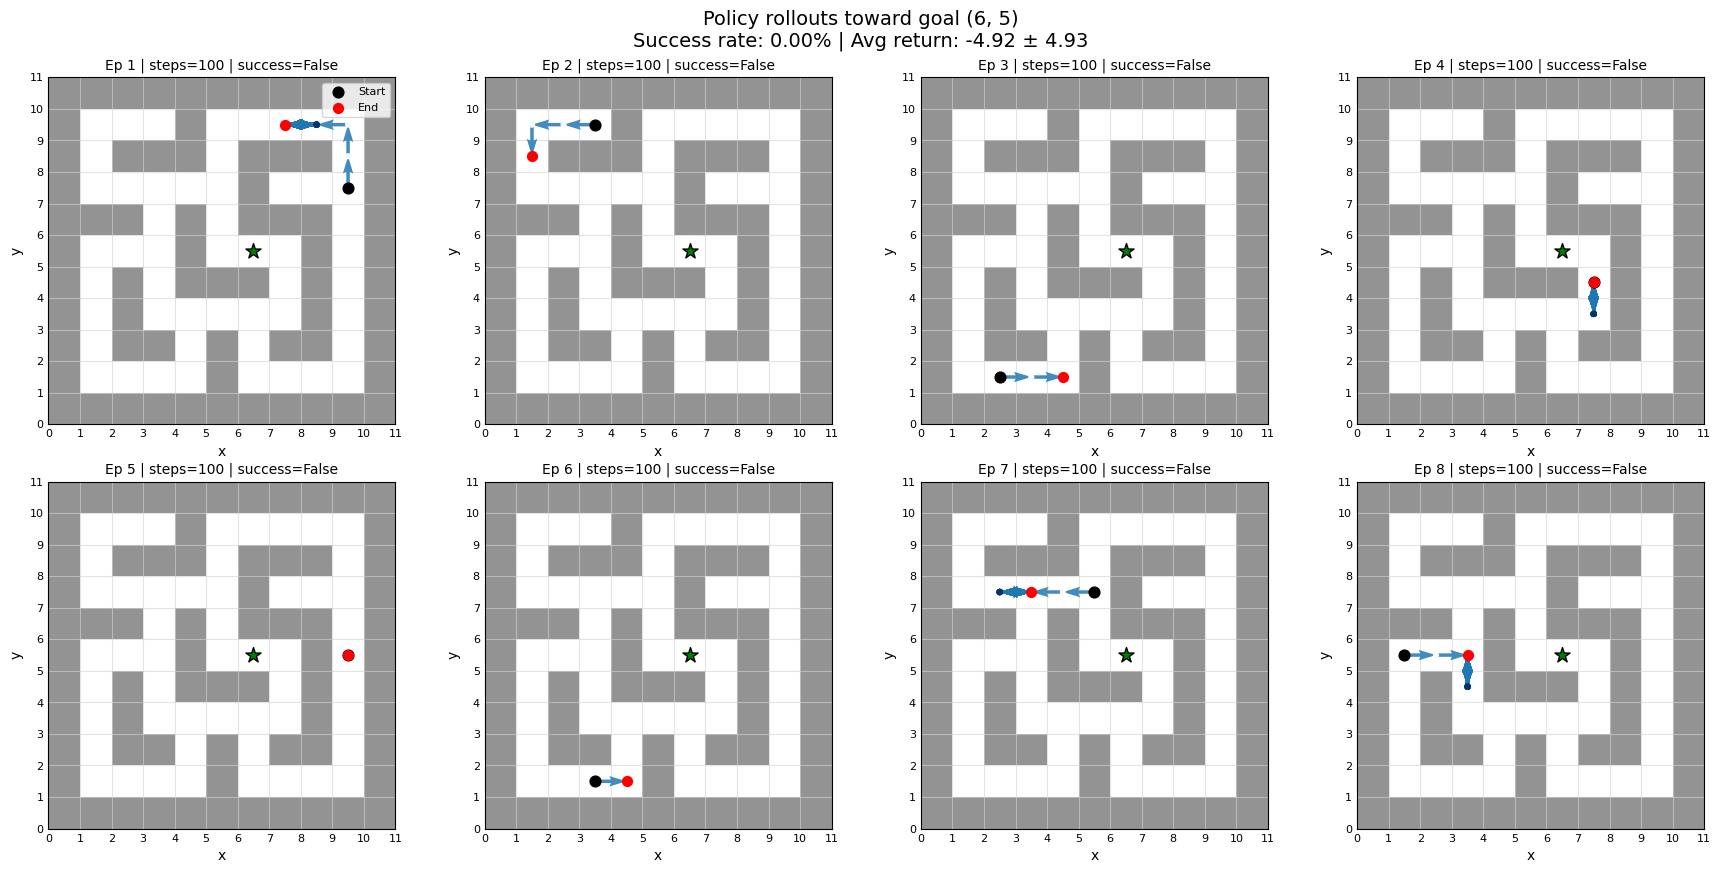

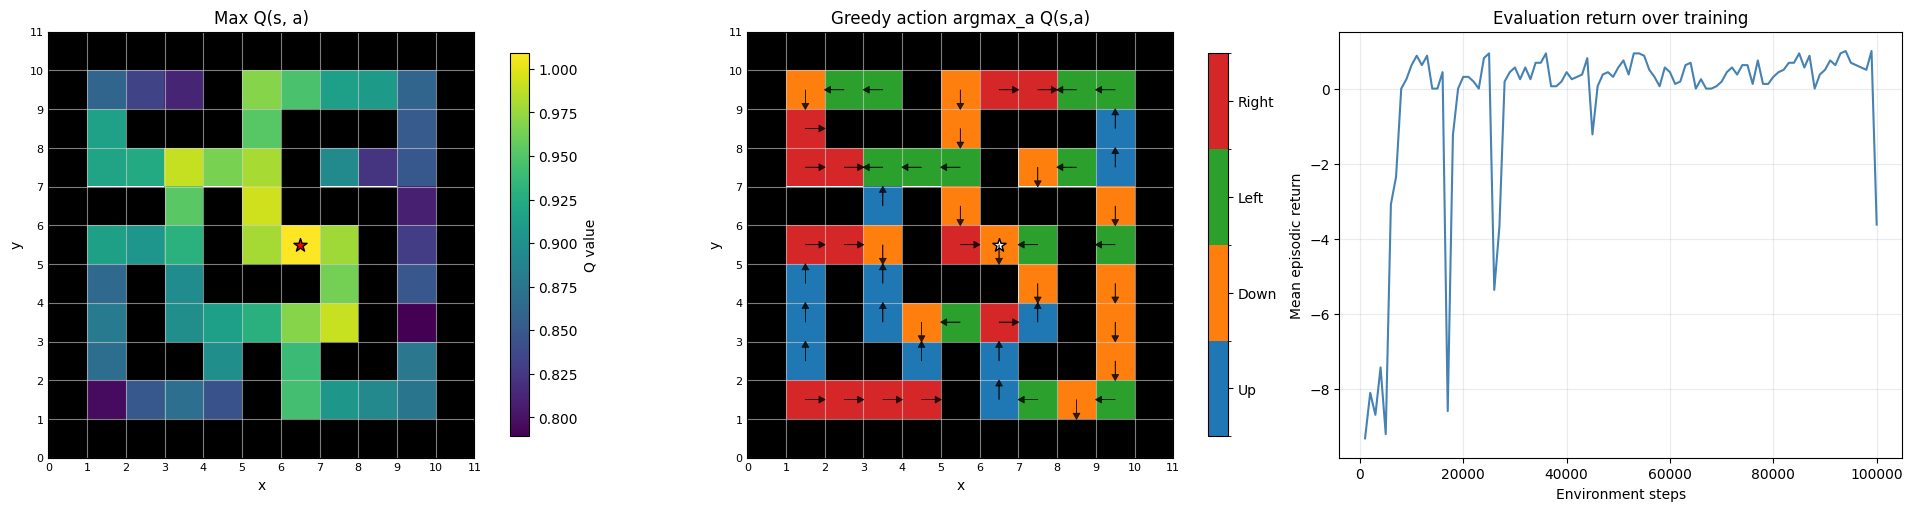

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.782041  4.4798727 4.3693986 4.0361633 3.9086044]
cumulative variance (first 5 dims): [0.11131209 0.20900142 0.3019321  0.38122845 0.45559186]
cos(phi(s,a), psi/task): mean=0.0029, std=0.1332


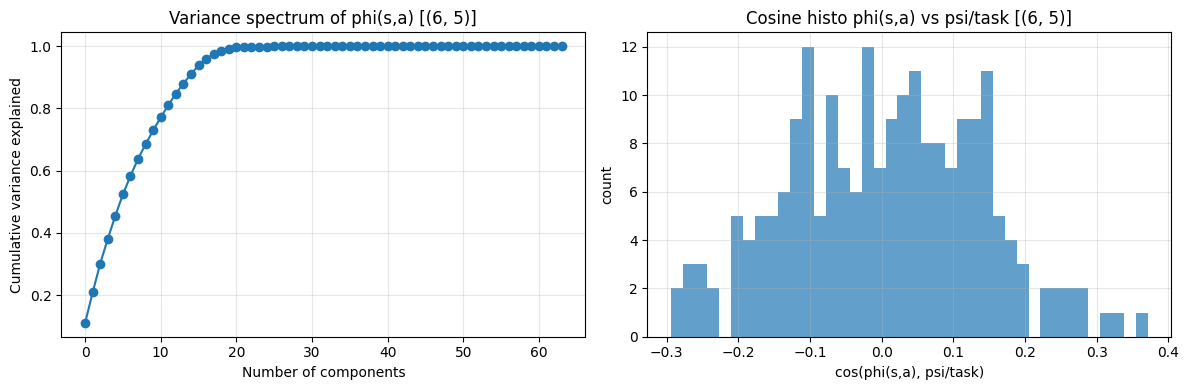


Goal embedding cosine similarity matrix:
     (6, 5)
  (6, 5)      1.000

----- seed 42, goal (5, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-4.944 | eval_len=100.0 | eval_var=24.4475 | ma=-4.944 | best_ma=-4.944 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-3.712 | eval_len=100.0 | eval_var=22.9786 | ma=-4.328 | best_ma=-4.328 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-3.719 | eval_len=100.0 | eval_var=23.0528 | ma=-4.125 | best_ma=-4.125 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000


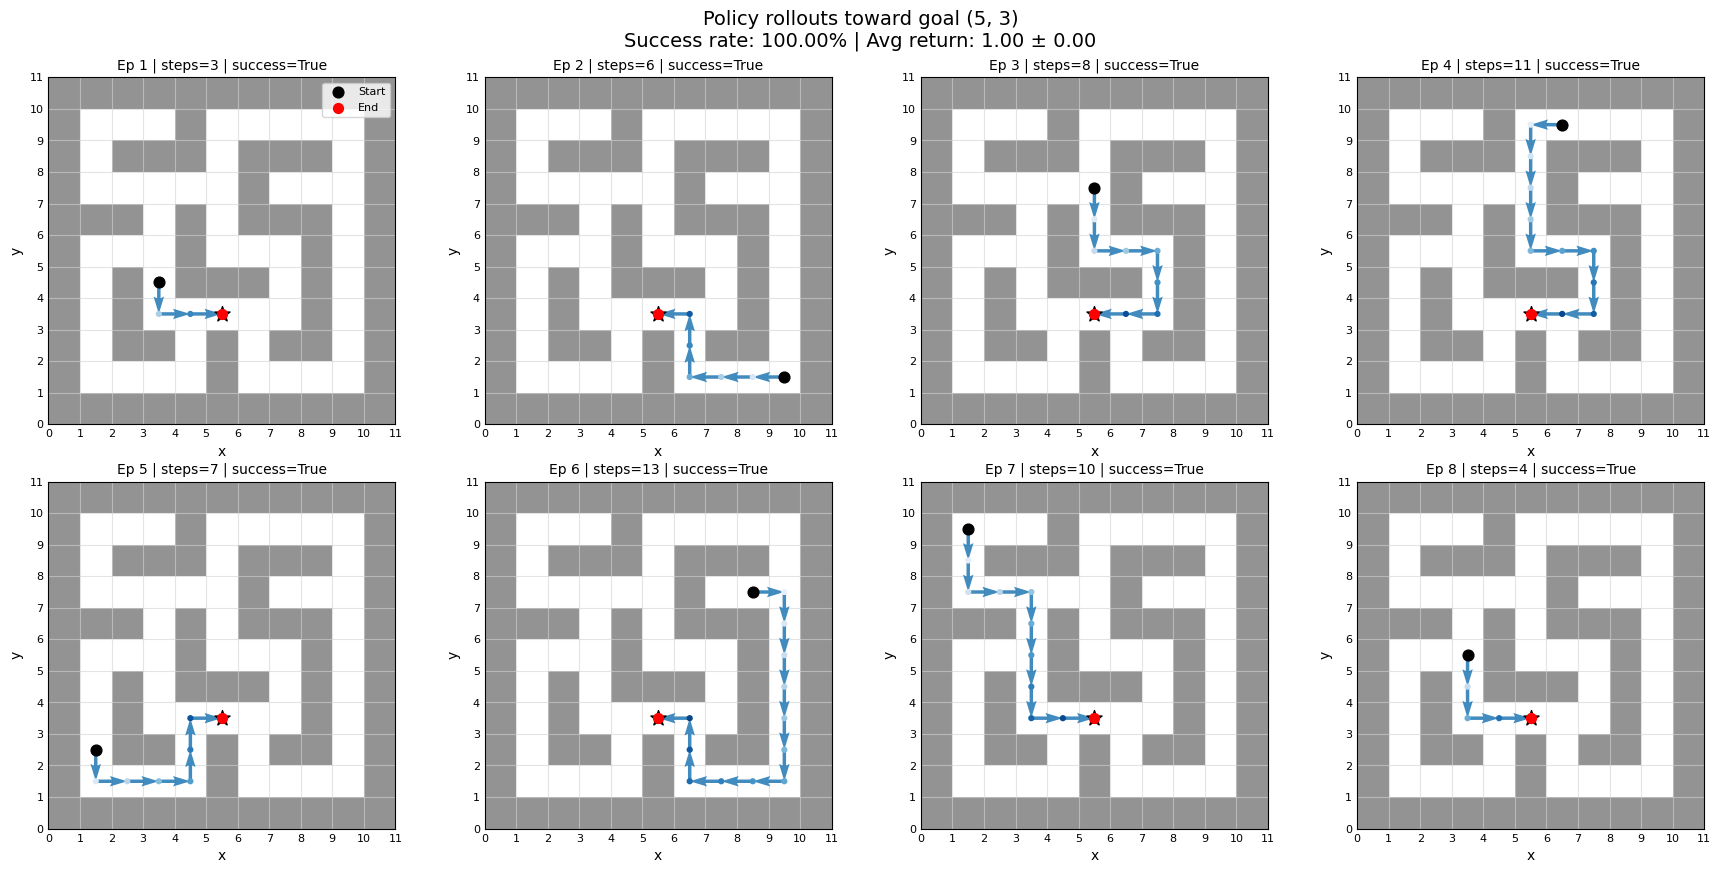

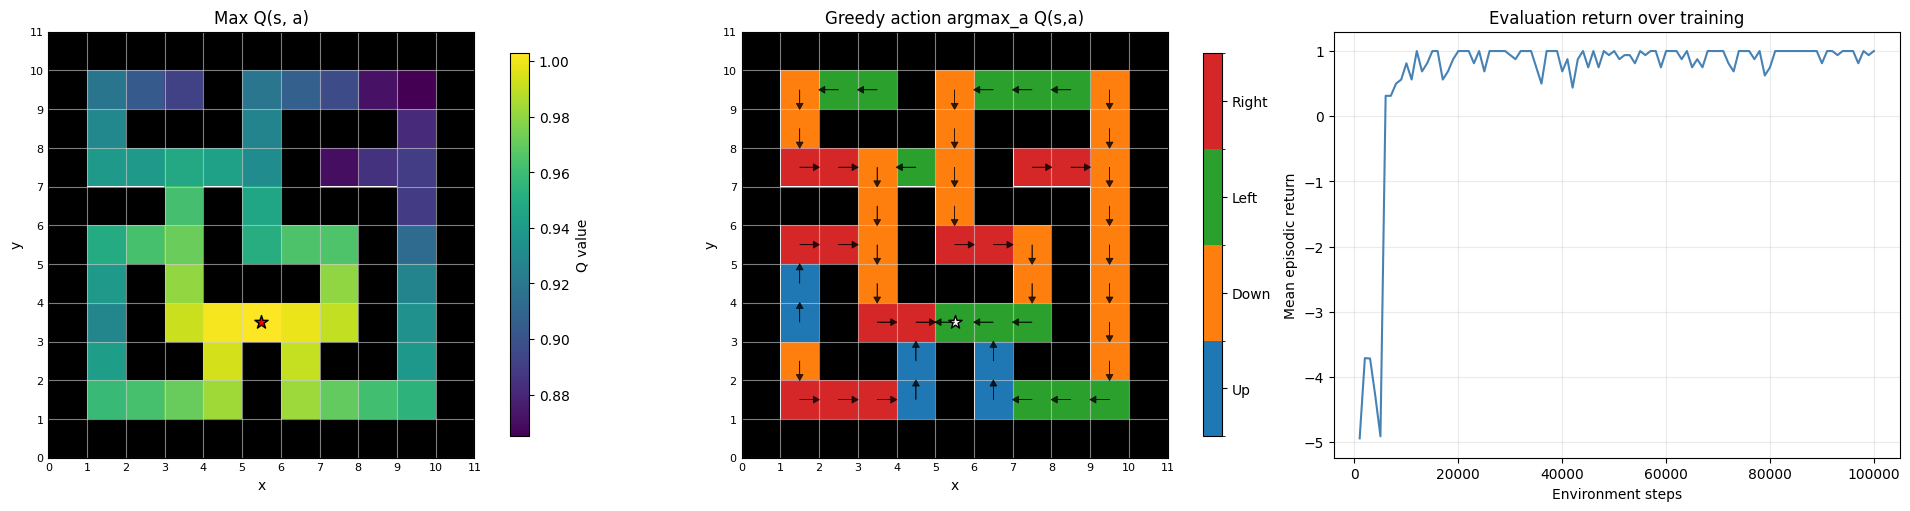

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.782041  4.4798727 4.3693986 4.0361633 3.9086044]
cumulative variance (first 5 dims): [0.11131209 0.20900142 0.3019321  0.38122845 0.45559186]
cos(phi(s,a), psi/task): mean=-0.0012, std=0.1224


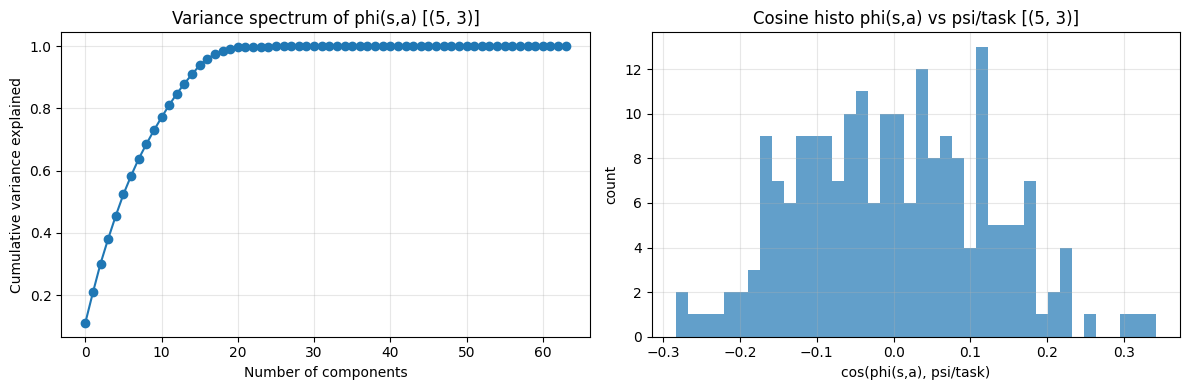


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)
  (6, 5)      1.000      0.950
  (5, 3)      0.950      1.000

Off-diagonal mean similarity: 0.950
Off-diagonal min similarity: 0.950
Off-diagonal max similarity: 0.950

----- seed 42, goal (3, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.250 | eval_len=76.1 | eval_var=0.1875 | ma=0.250 | best_ma=0.250 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=0.312 | eval_len=70.4 | eval_var=0.2148 | ma=0.281 | best_ma=0.281 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=0.250 | eval_len=76.1 | eval_var=0.1875 | ma=0.271 | best_ma=0.281 | plateau=1 | TD=0.0000 | 

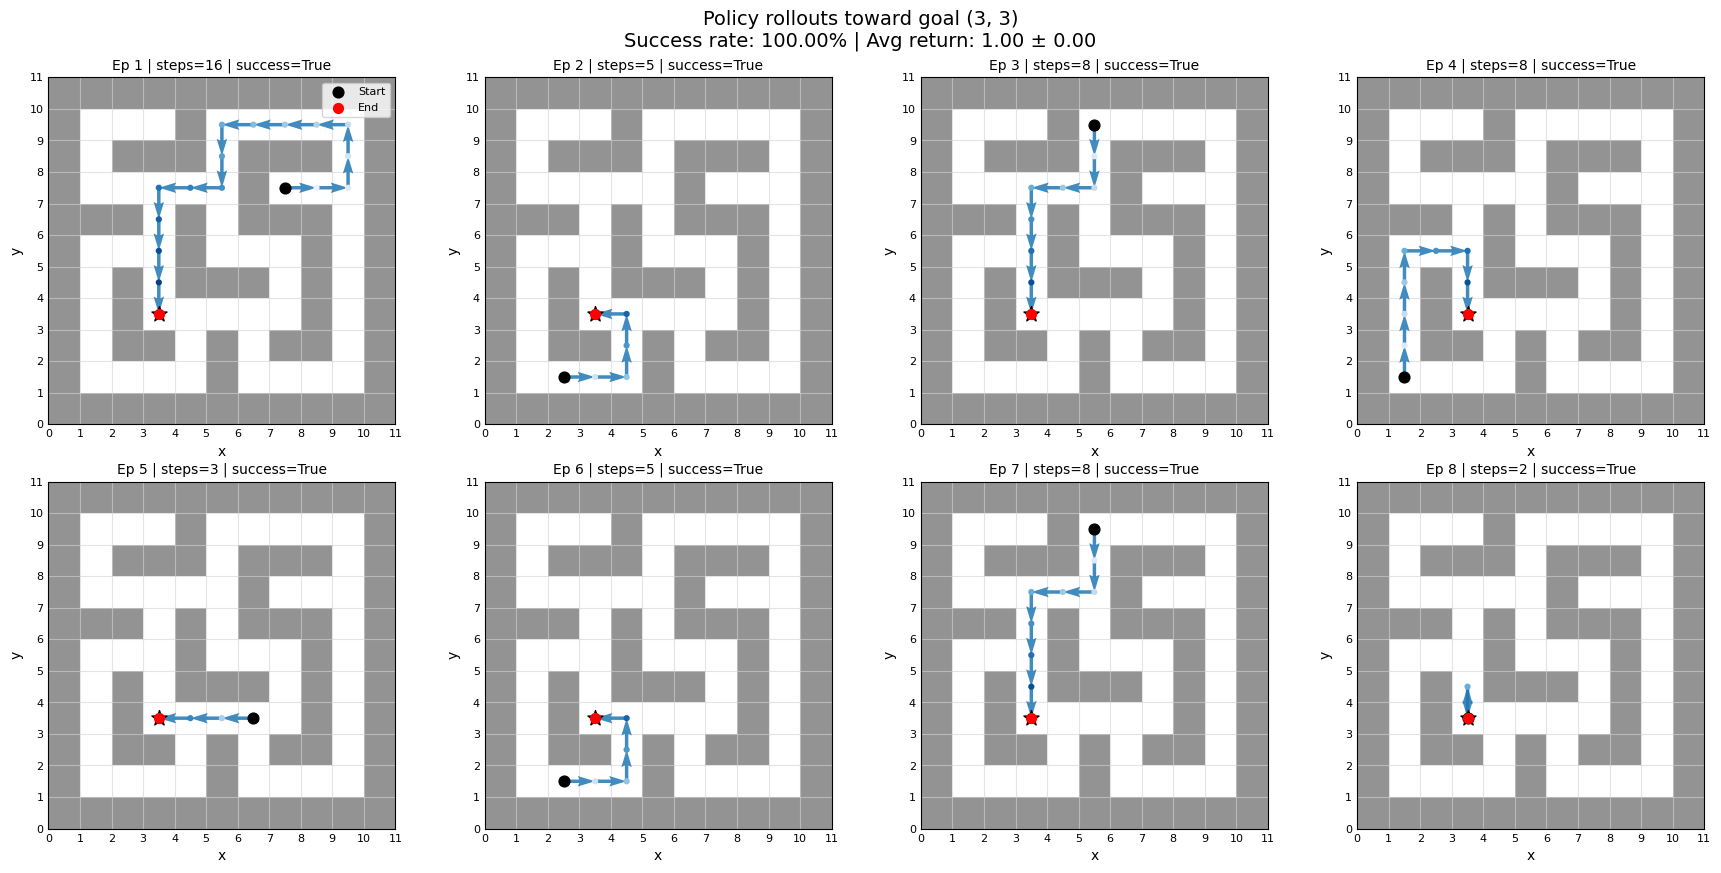

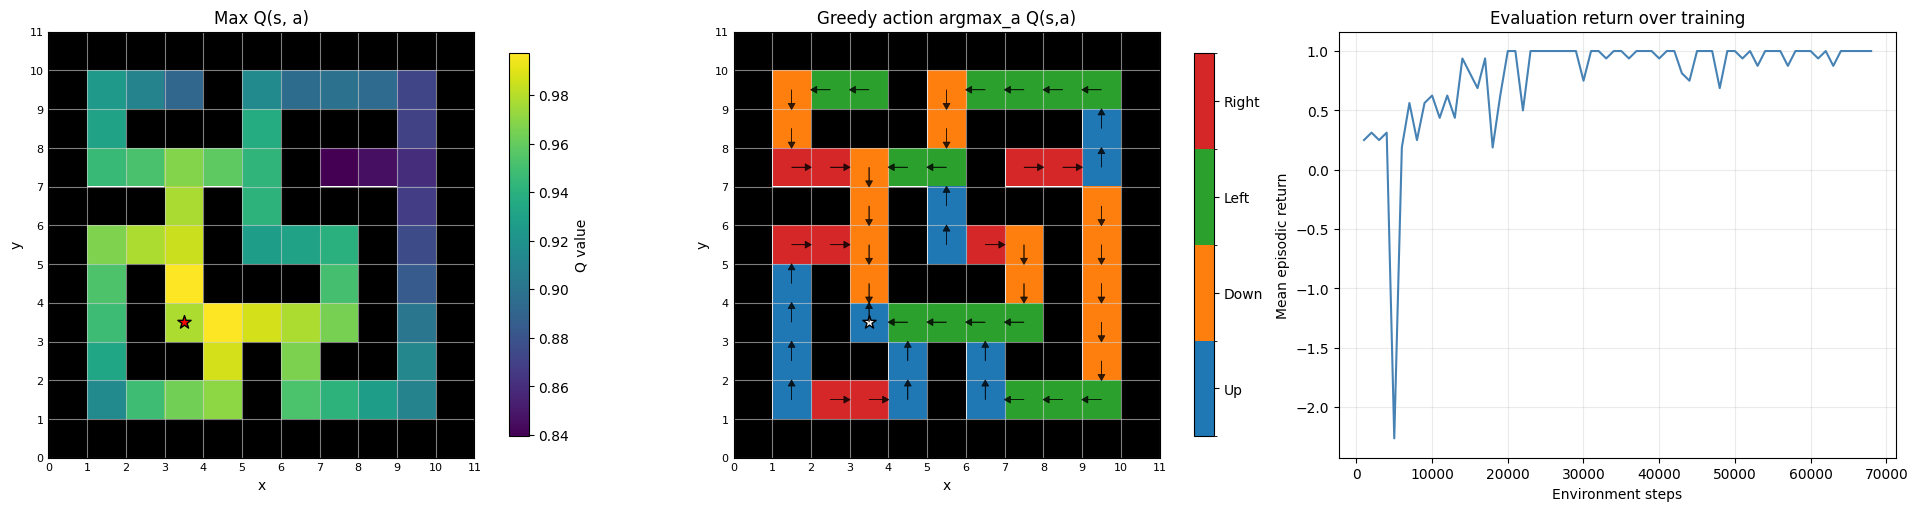

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.782041  4.4798727 4.3693986 4.0361633 3.9086044]
cumulative variance (first 5 dims): [0.11131209 0.20900142 0.3019321  0.38122845 0.45559186]
cos(phi(s,a), psi/task): mean=-0.0027, std=0.1144


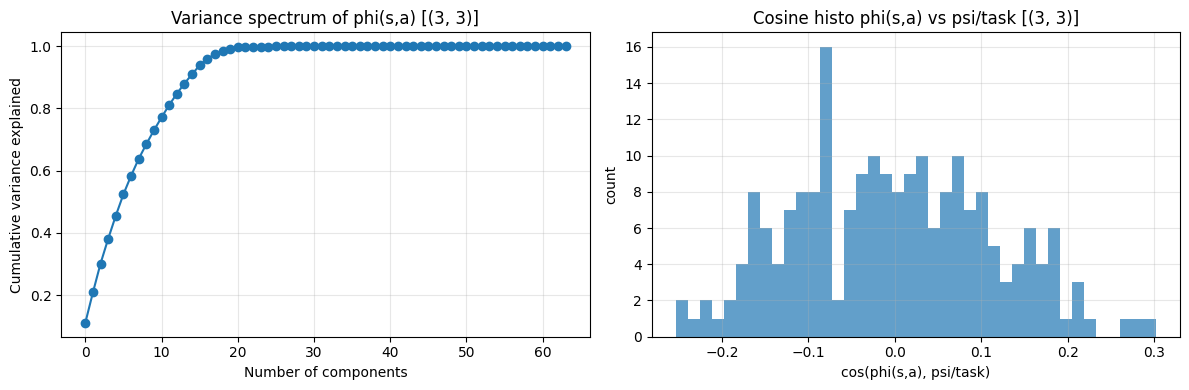


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)
  (6, 5)      1.000      0.950      0.902
  (5, 3)      0.950      1.000      0.990
  (3, 3)      0.902      0.990      1.000

Off-diagonal mean similarity: 0.947
Off-diagonal min similarity: 0.902
Off-diagonal max similarity: 0.990

----- seed 42, goal (3, 6) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.438 | eval_len=59.5 | eval_var=0.2461 | ma=0.438 | best_ma=0.438 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=0.438 | eval_len=58.4 | eval_var=0.2461 | ma=0.438 | best_ma=0.438 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=0.625 | eval_len=4

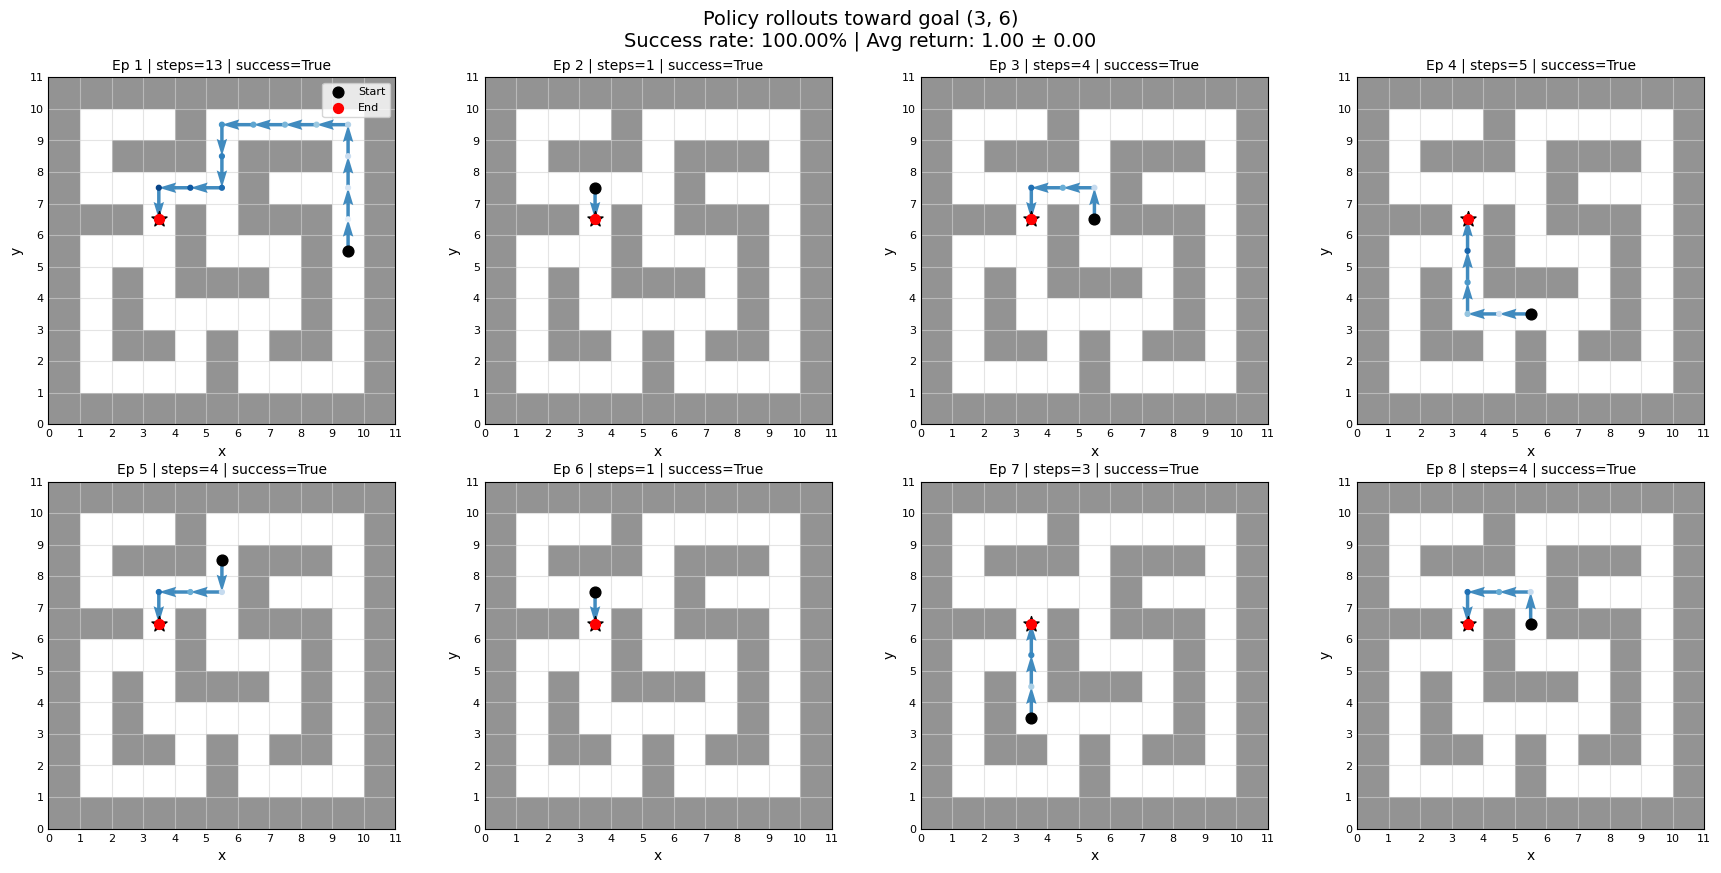

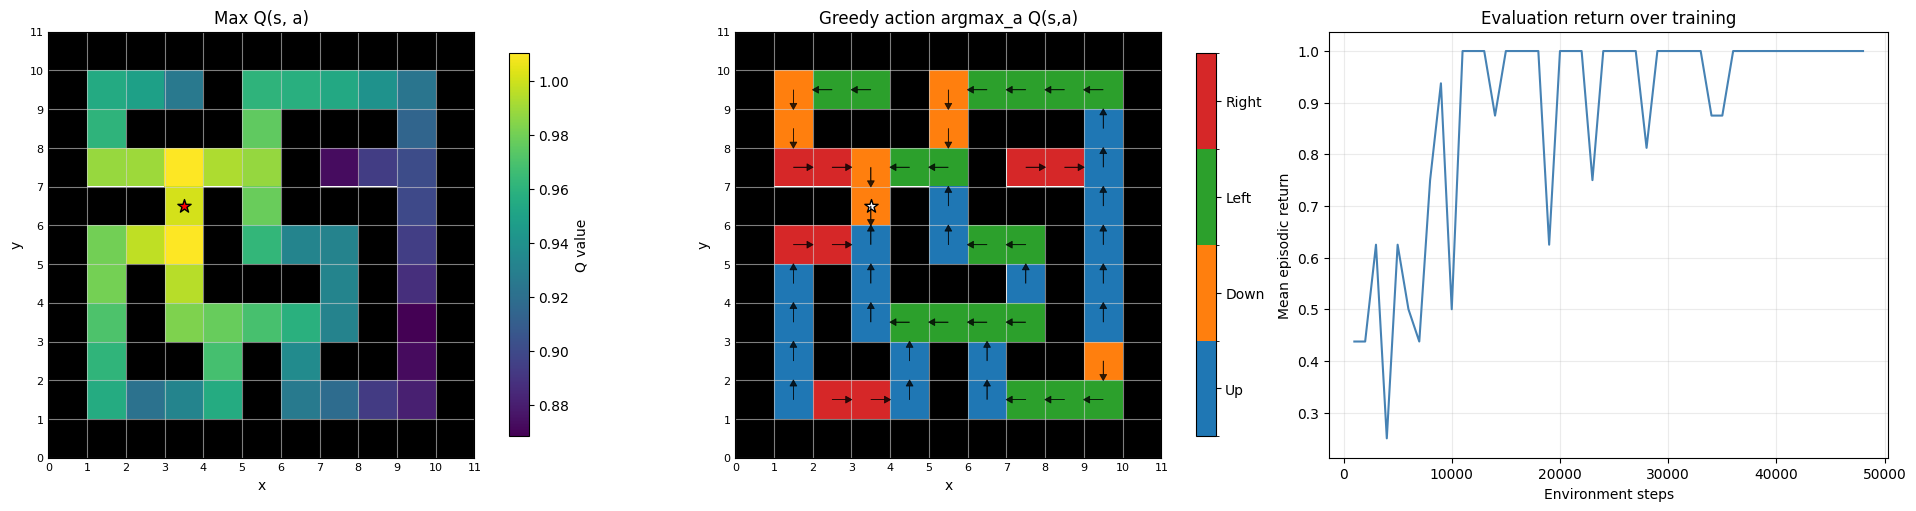

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.782041  4.4798727 4.3693986 4.0361633 3.9086044]
cumulative variance (first 5 dims): [0.11131209 0.20900142 0.3019321  0.38122845 0.45559186]
cos(phi(s,a), psi/task): mean=-0.0028, std=0.1120


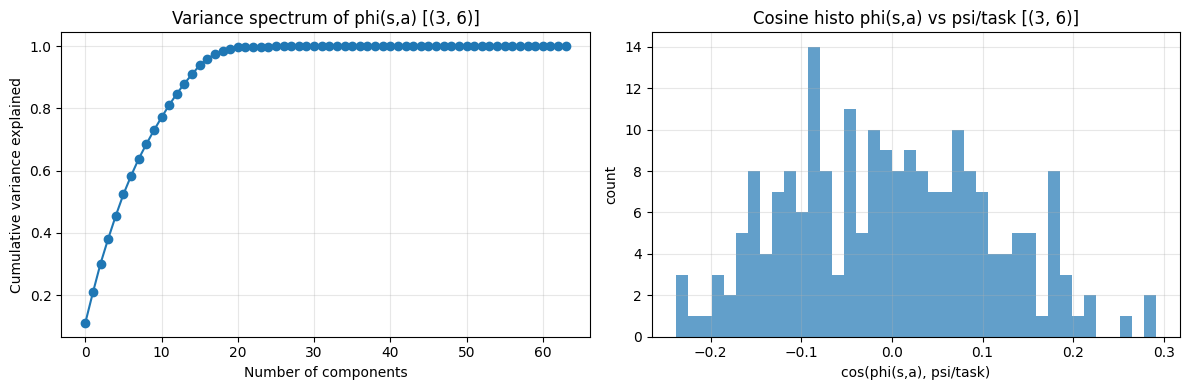


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)
  (6, 5)      1.000      0.950      0.902      0.883
  (5, 3)      0.950      1.000      0.990      0.982
  (3, 3)      0.902      0.990      1.000      0.998
  (3, 6)      0.883      0.982      0.998      1.000

Off-diagonal mean similarity: 0.951
Off-diagonal min similarity: 0.883
Off-diagonal max similarity: 0.998

----- seed 42, goal (7, 9) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.125 | eval_len=88.0 | eval_var=0.1094 | ma=0.125 | best_ma=0.125 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=0.062 | eval_len=94.2 | eval_var=0.0586 | ma=0.094 | best_ma=0.125 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.00000000

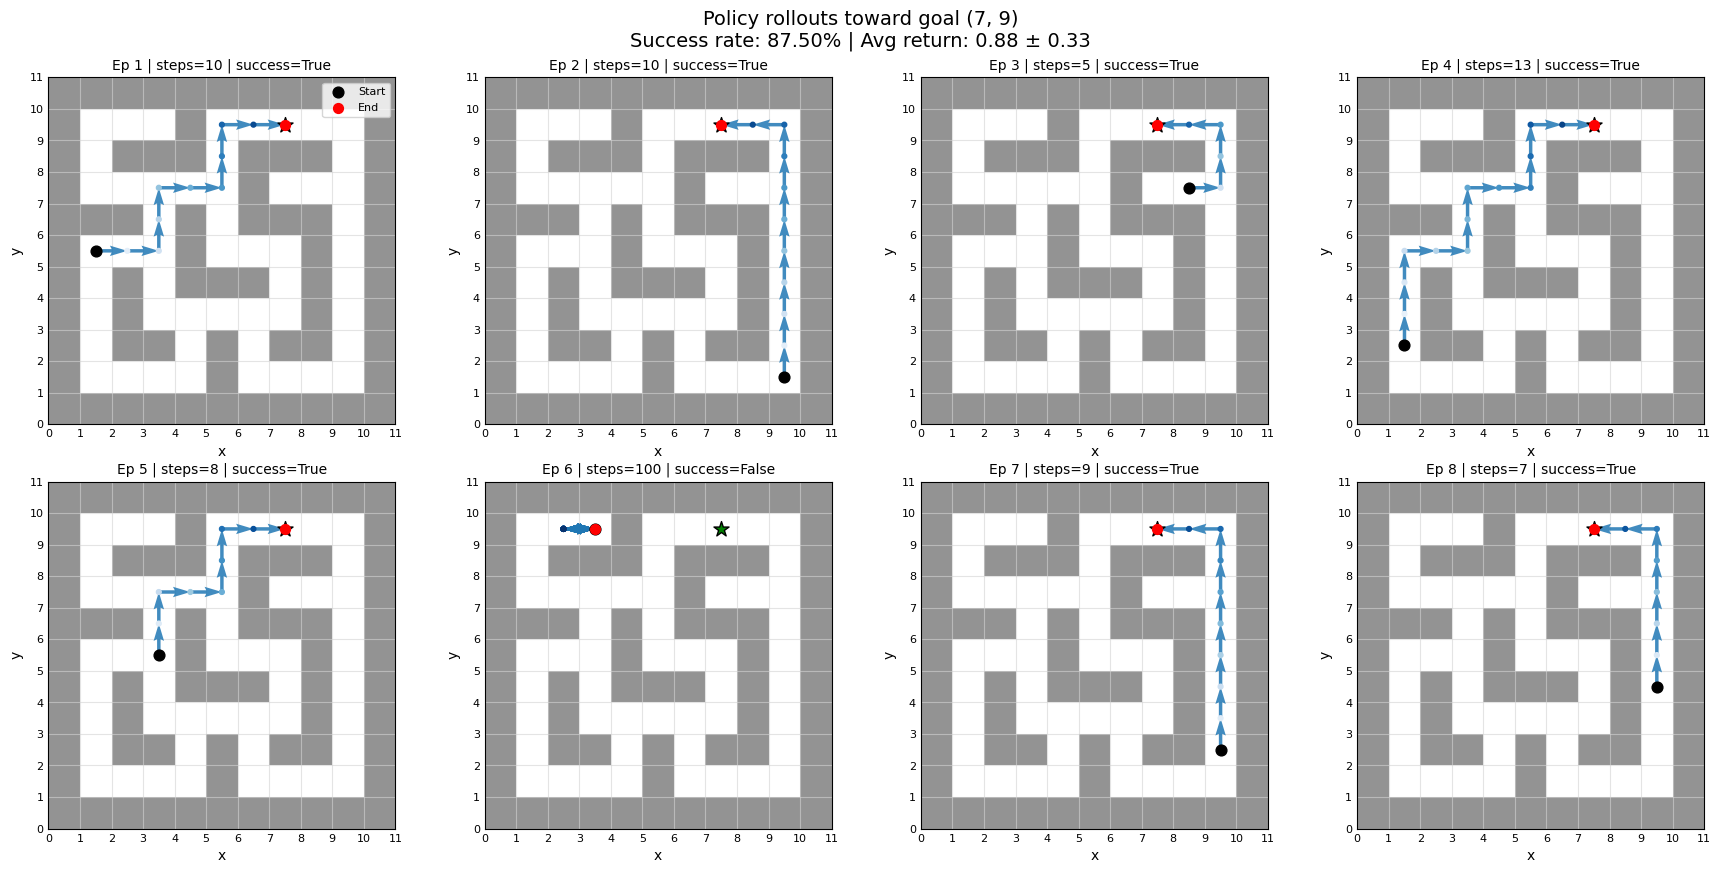

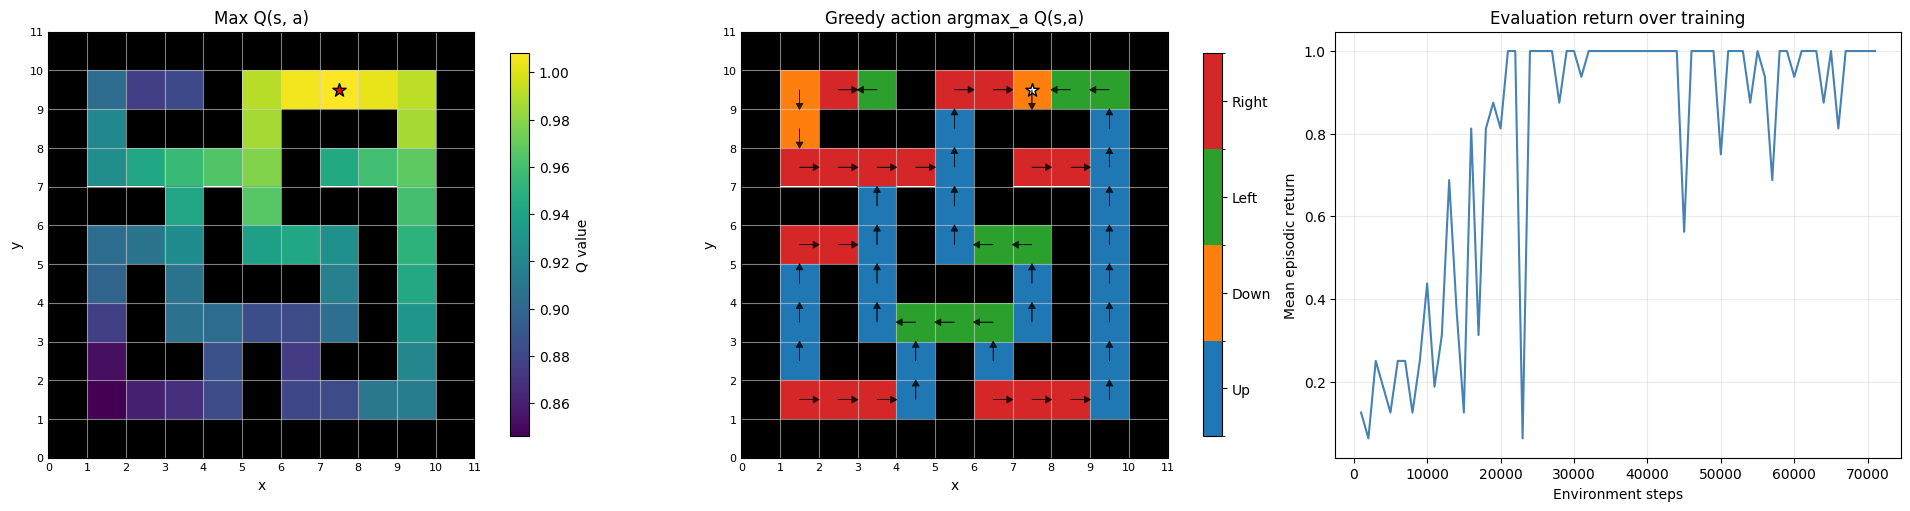

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.782041  4.4798727 4.3693986 4.0361633 3.9086044]
cumulative variance (first 5 dims): [0.11131209 0.20900142 0.3019321  0.38122845 0.45559186]
cos(phi(s,a), psi/task): mean=-0.0034, std=0.1074


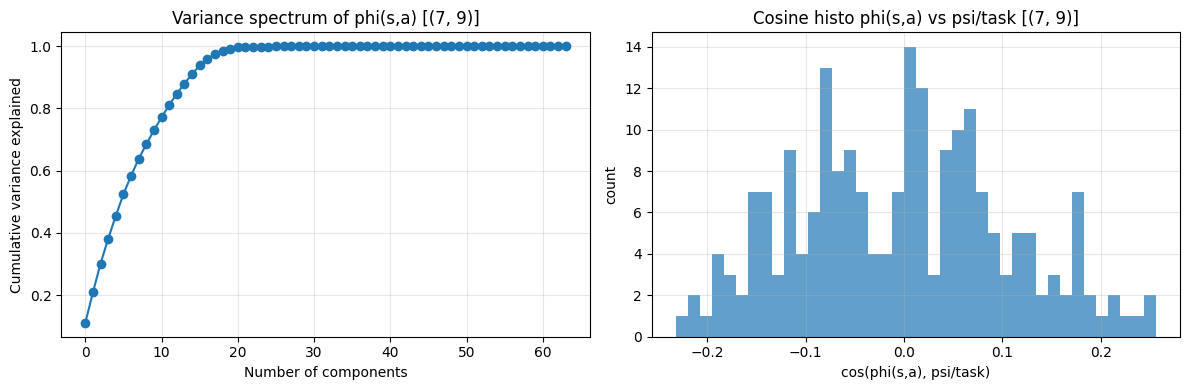


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)     (7, 9)
  (6, 5)      1.000      0.950      0.902      0.883      0.845
  (5, 3)      0.950      1.000      0.990      0.982      0.957
  (3, 3)      0.902      0.990      1.000      0.998      0.985
  (3, 6)      0.883      0.982      0.998      1.000      0.993
  (7, 9)      0.845      0.957      0.985      0.993      1.000

Off-diagonal mean similarity: 0.948
Off-diagonal min similarity: 0.845
Off-diagonal max similarity: 0.998

SEED 123


----- seed 123, goal (6, 5) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-9.175 | eval_len=93.8 | eval_var=6.9194 | ma=-9.175 | best_ma=-9.175 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-9.225 | eval_len=93.8 | eval_var=6.9806 | ma=-9.200 | best_ma=-9.175 | platea

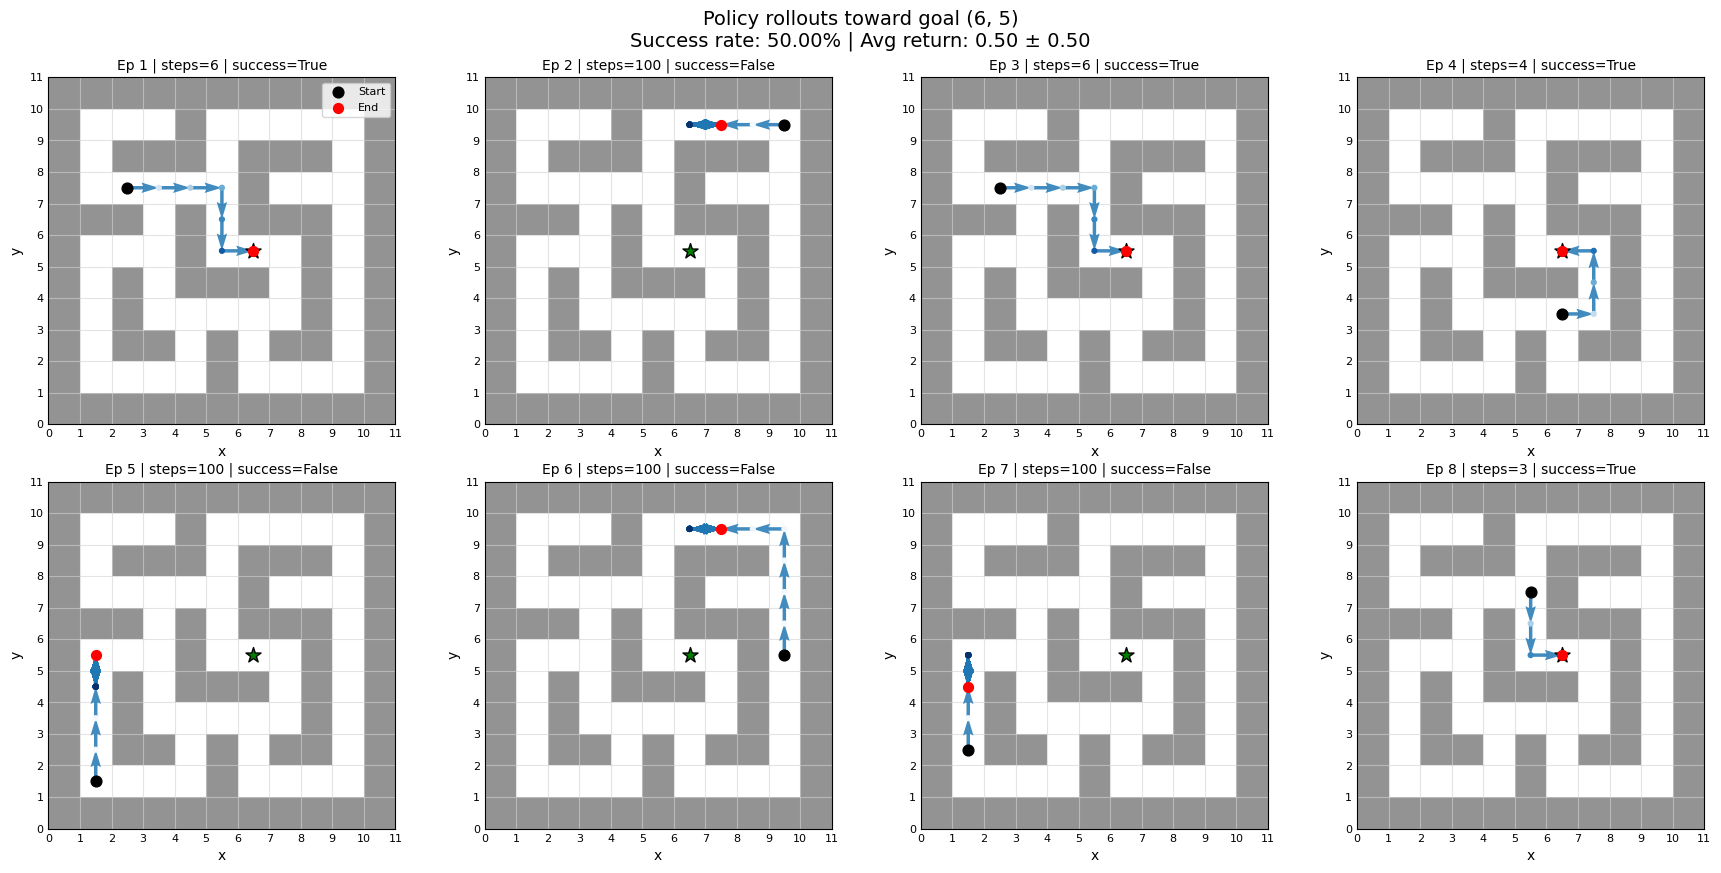

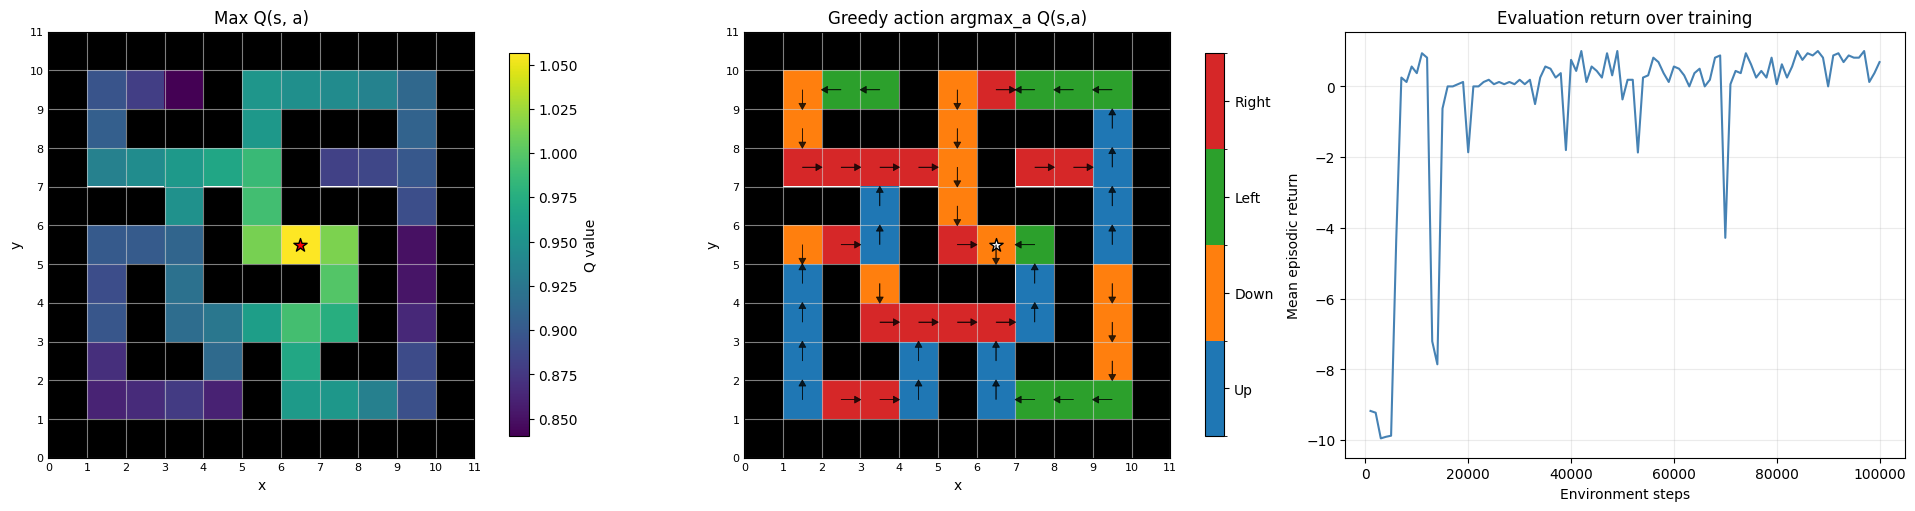

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.748032  4.3738    4.05721   3.998384  3.7924993]
cumulative variance (first 5 dims): [0.10889991 0.20130973 0.28082585 0.35805288 0.4275315 ]
cos(phi(s,a), psi/task): mean=-0.0158, std=0.1069


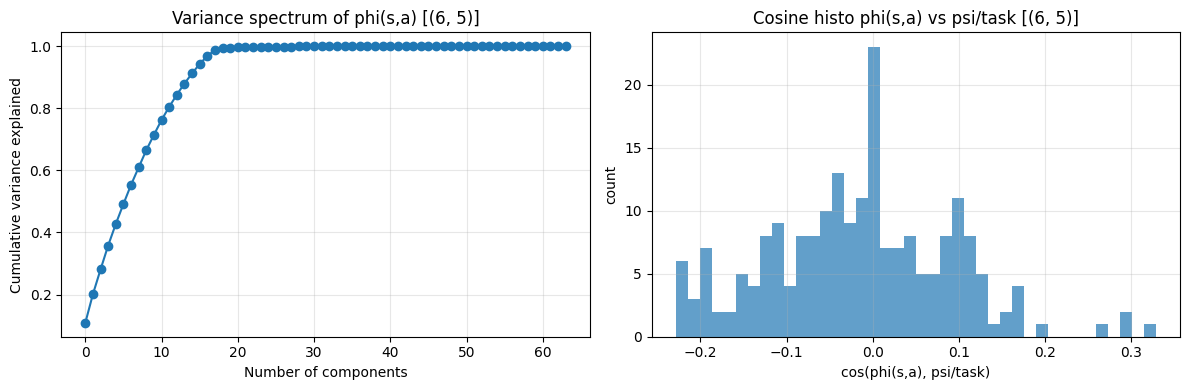


Goal embedding cosine similarity matrix:
     (6, 5)
  (6, 5)      1.000

----- seed 123, goal (5, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-6.981 | eval_len=93.9 | eval_var=17.5028 | ma=-6.981 | best_ma=-6.981 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-7.062 | eval_len=94.0 | eval_var=17.9236 | ma=-7.022 | best_ma=-6.981 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-5.375 | eval_len=100.0 | eval_var=22.5294 | ma=-6.473 | best_ma=-6.473 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[

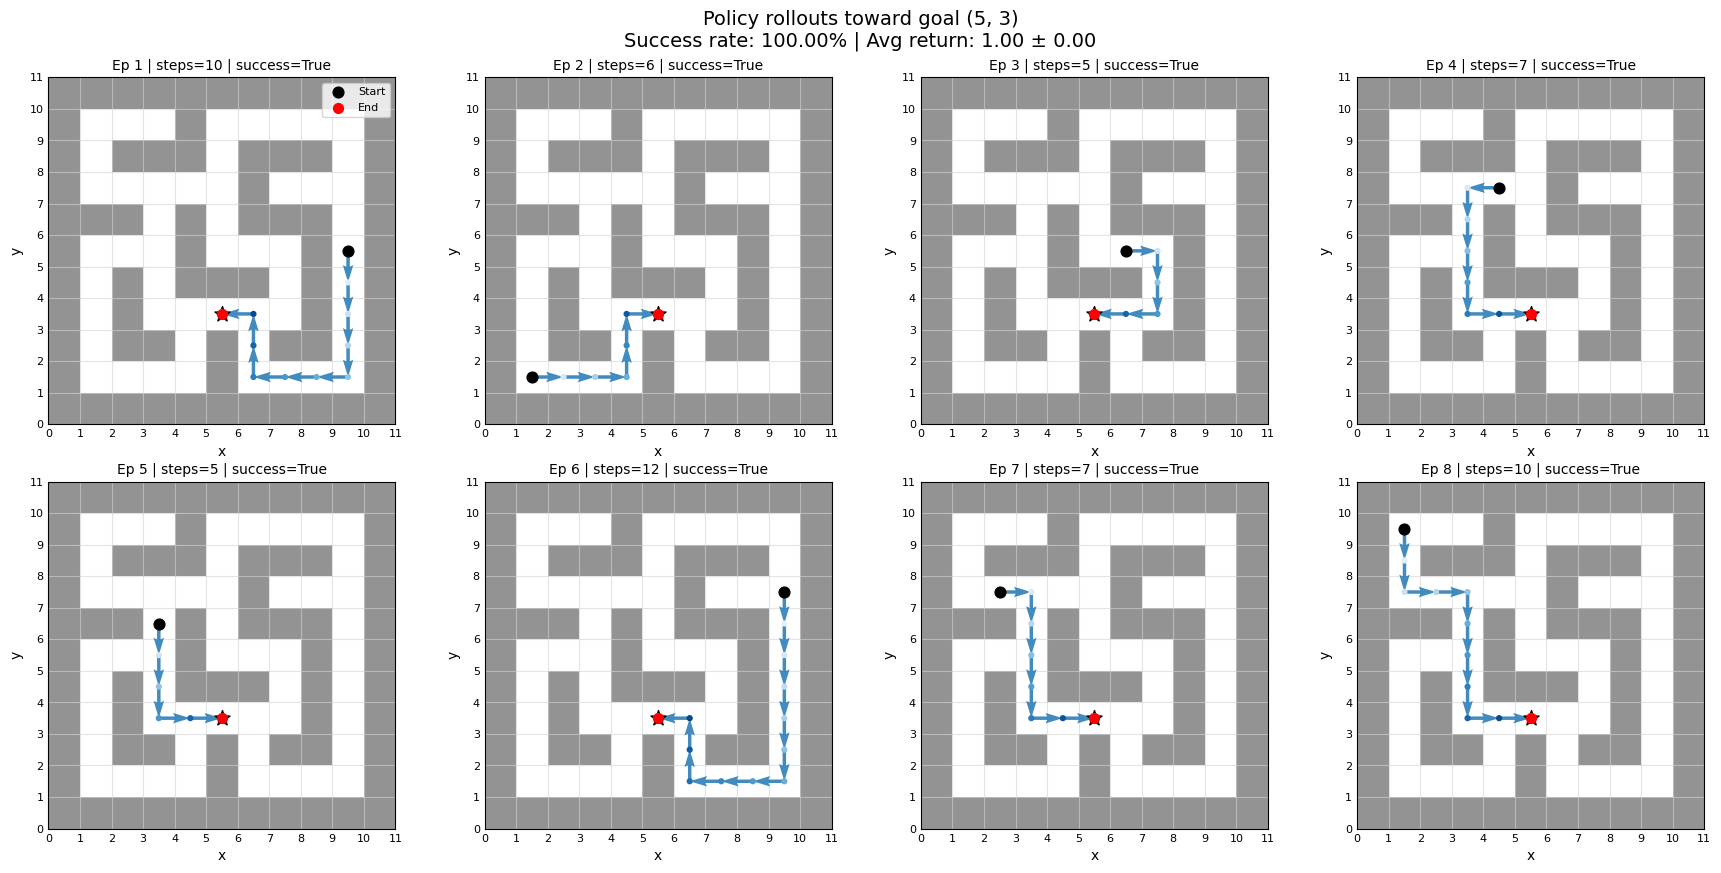

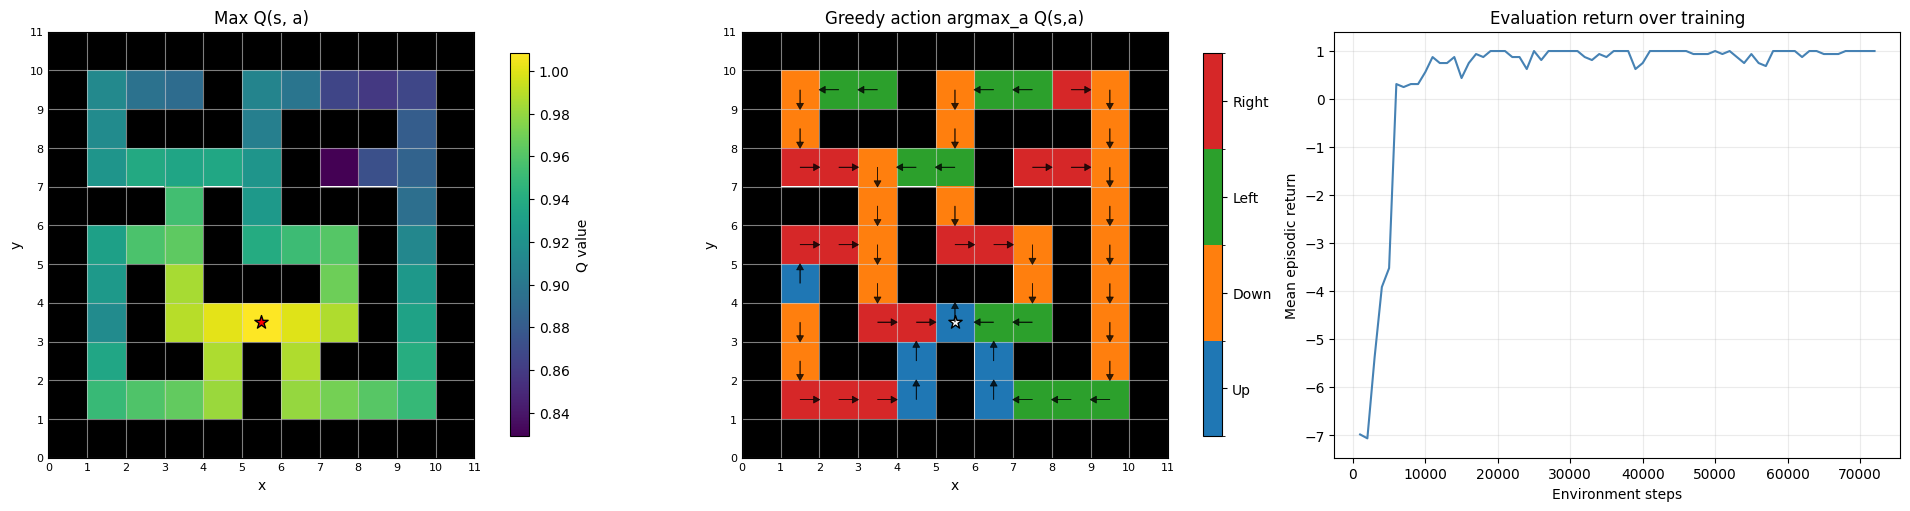

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.748032  4.3738    4.05721   3.998384  3.7924993]
cumulative variance (first 5 dims): [0.10889991 0.20130973 0.28082585 0.35805288 0.4275315 ]
cos(phi(s,a), psi/task): mean=-0.0147, std=0.1022


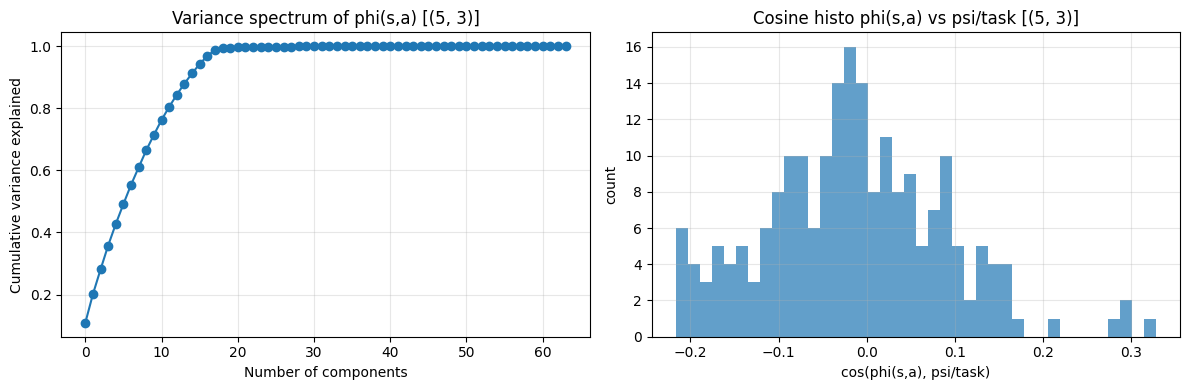


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)
  (6, 5)      1.000      0.981
  (5, 3)      0.981      1.000

Off-diagonal mean similarity: 0.981
Off-diagonal min similarity: 0.981
Off-diagonal max similarity: 0.981

----- seed 123, goal (3, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-5.494 | eval_len=64.2 | eval_var=25.4381 | ma=-5.494 | best_ma=-5.494 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-6.787 | eval_len=76.7 | eval_var=20.3298 | ma=-6.141 | best_ma=-5.494 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-4.100 | eval_len=52.6 | eval_var=26.0737 | ma=-5.460 | best_ma=-5.460 | plateau=0 |

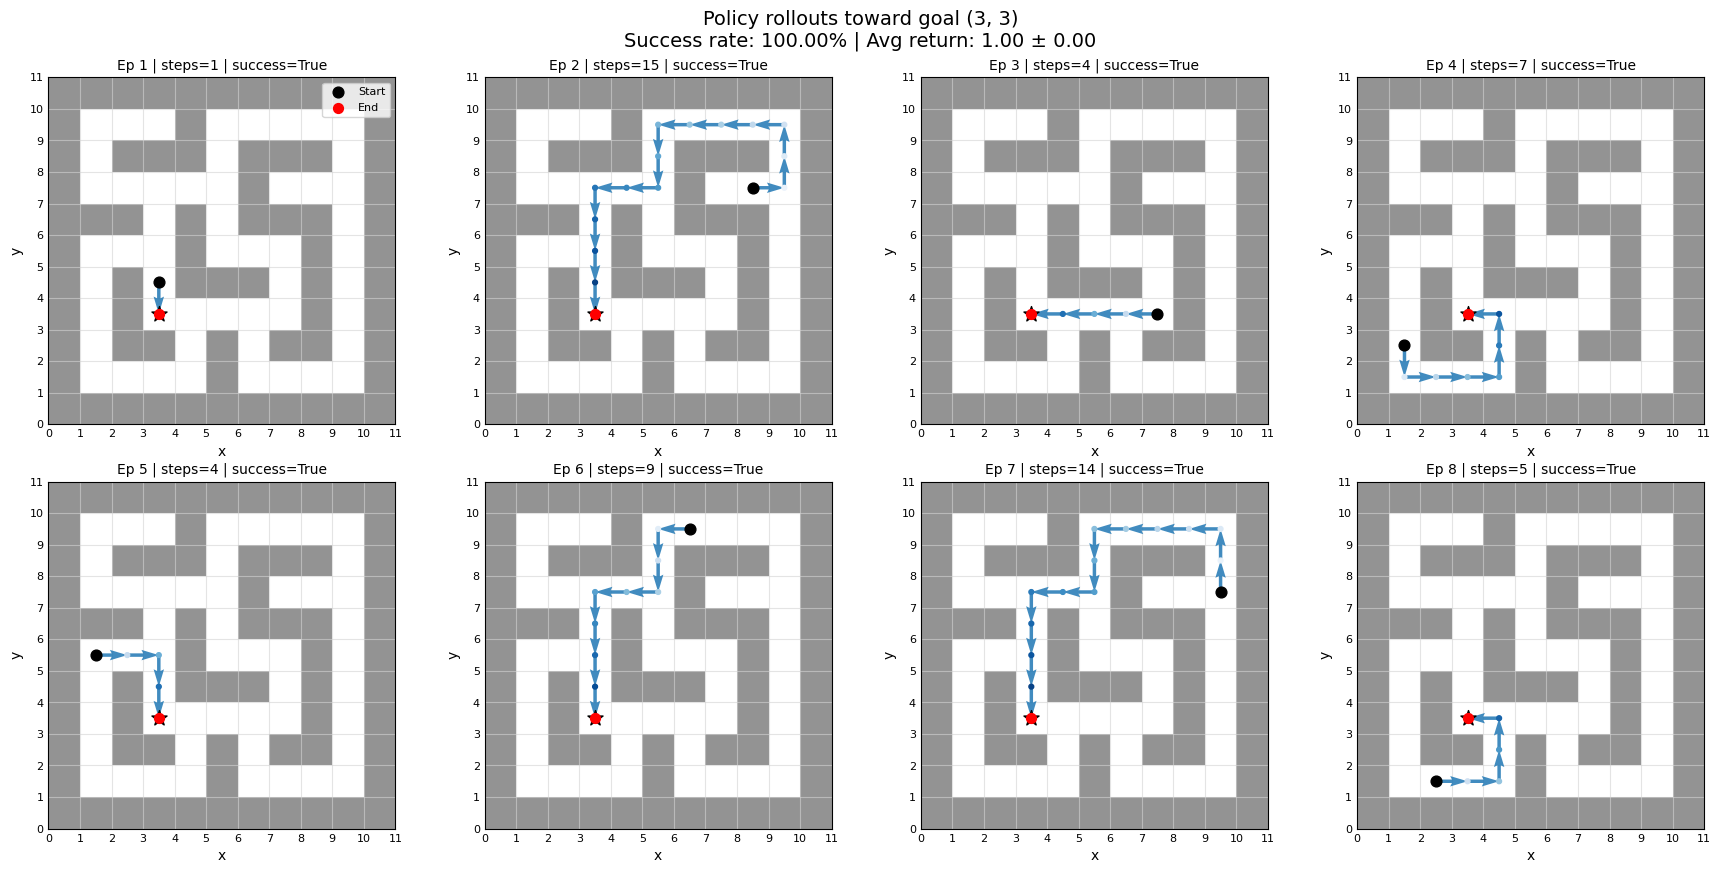

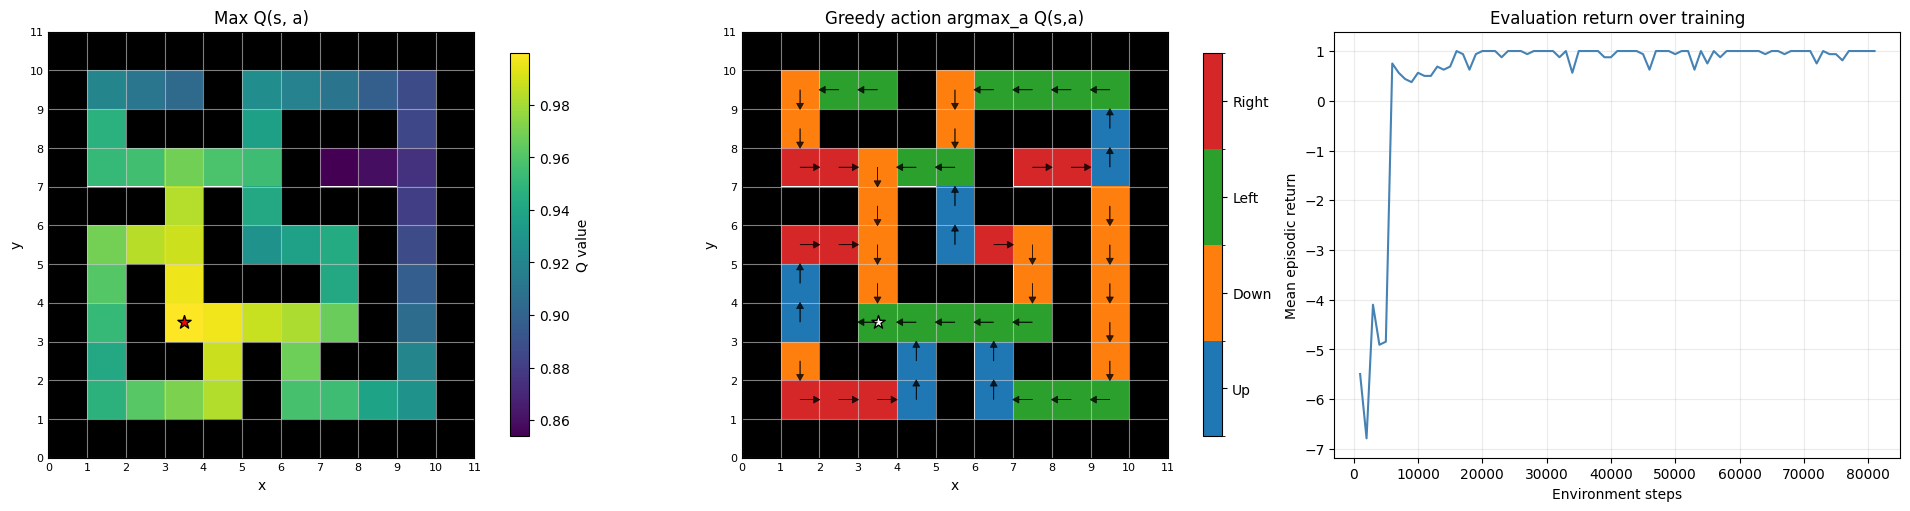

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.748032  4.3738    4.05721   3.998384  3.7924993]
cumulative variance (first 5 dims): [0.10889991 0.20130973 0.28082585 0.35805288 0.4275315 ]
cos(phi(s,a), psi/task): mean=-0.0140, std=0.1013


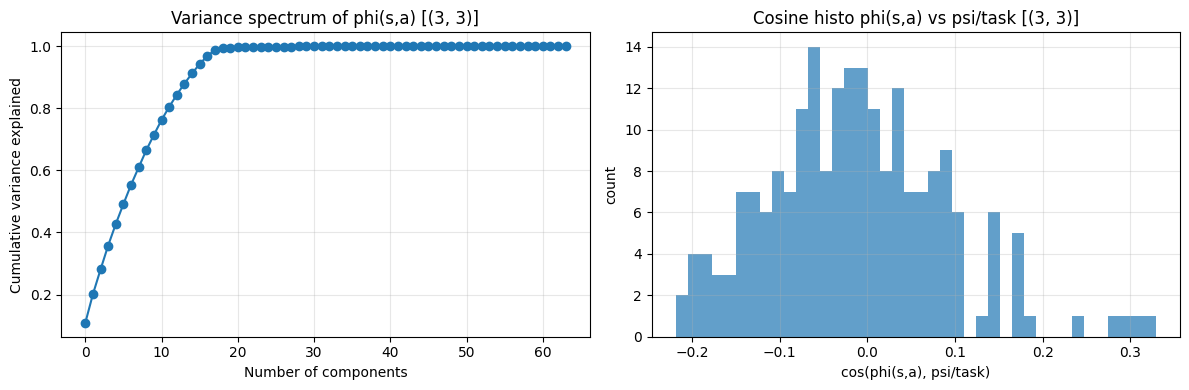


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)
  (6, 5)      1.000      0.981      0.943
  (5, 3)      0.981      1.000      0.989
  (3, 3)      0.943      0.989      1.000

Off-diagonal mean similarity: 0.971
Off-diagonal min similarity: 0.943
Off-diagonal max similarity: 0.989

----- seed 123, goal (3, 6) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-2.831 | eval_len=42.0 | eval_var=24.5134 | ma=-2.831 | best_ma=-2.831 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-4.294 | eval_len=52.2 | eval_var=28.0381 | ma=-3.562 | best_ma=-2.831 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-4.237 | 

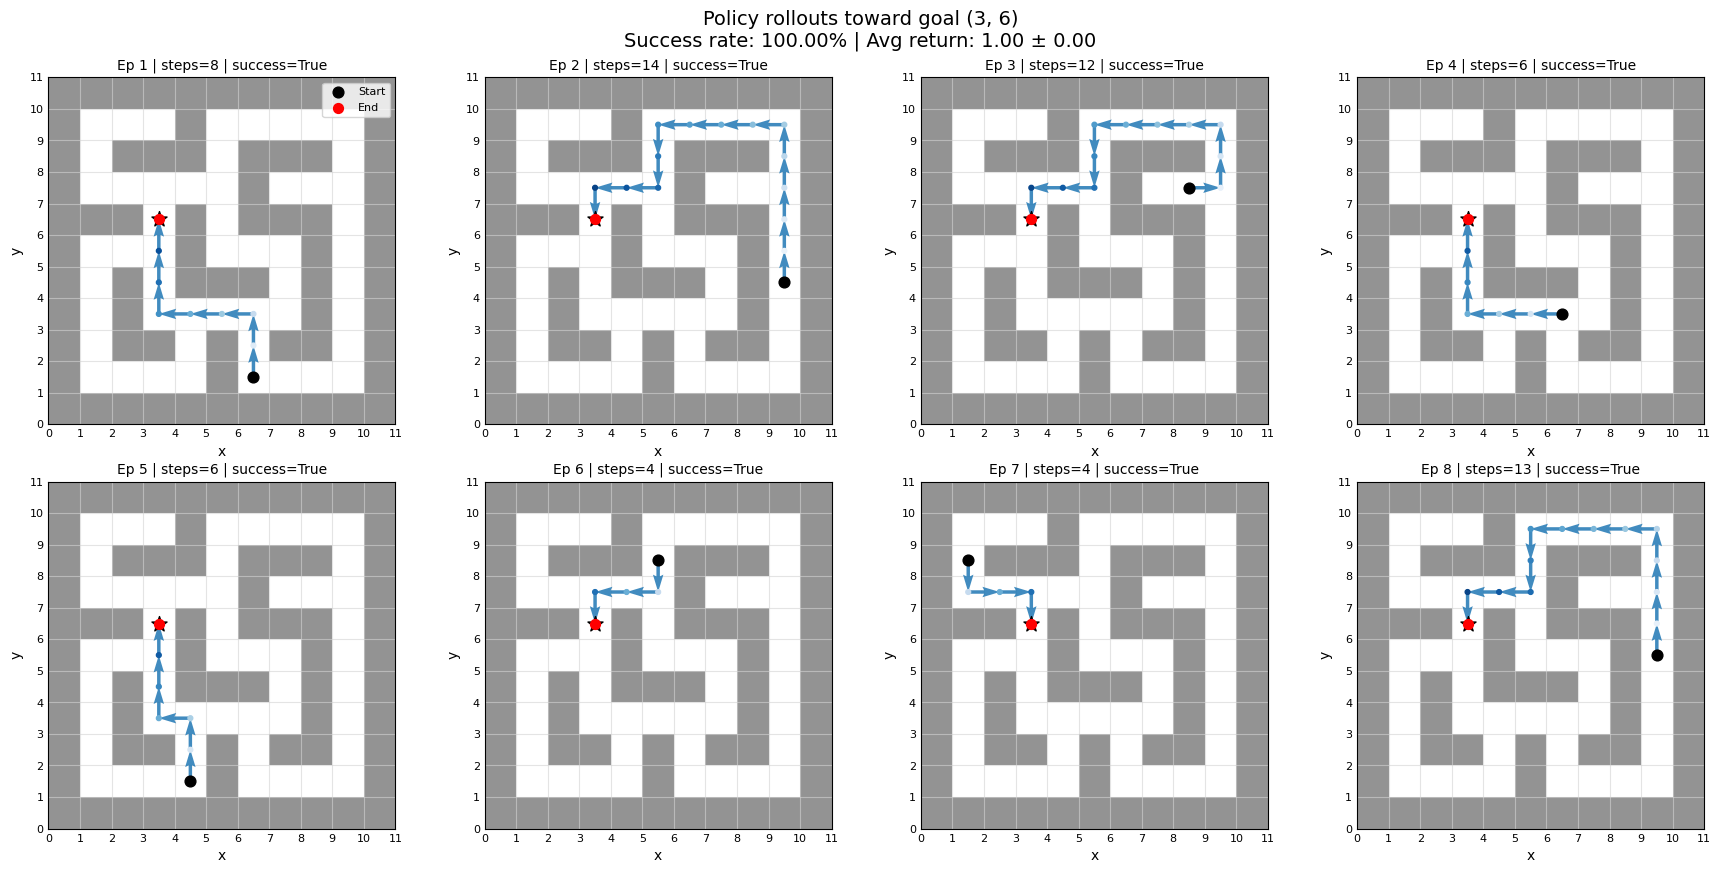

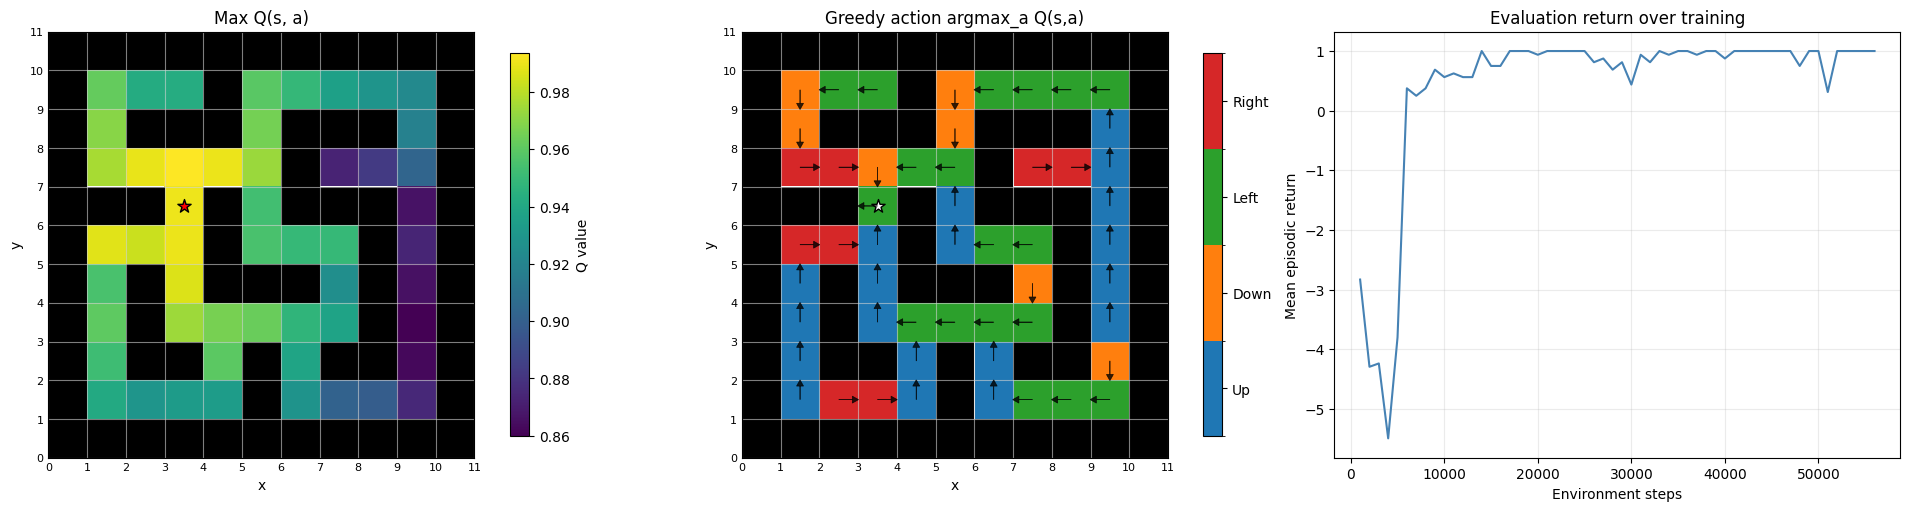

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.748032  4.3738    4.05721   3.998384  3.7924993]
cumulative variance (first 5 dims): [0.10889991 0.20130973 0.28082585 0.35805288 0.4275315 ]
cos(phi(s,a), psi/task): mean=-0.0139, std=0.1005


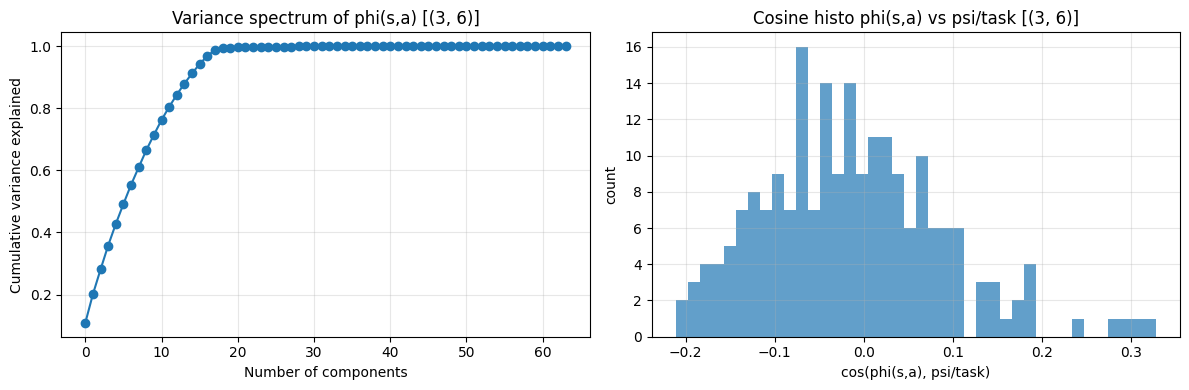


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)
  (6, 5)      1.000      0.981      0.943      0.913
  (5, 3)      0.981      1.000      0.989      0.972
  (3, 3)      0.943      0.989      1.000      0.996
  (3, 6)      0.913      0.972      0.996      1.000

Off-diagonal mean similarity: 0.966
Off-diagonal min similarity: 0.913
Off-diagonal max similarity: 0.996

----- seed 123, goal (7, 9) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-6.931 | eval_len=76.5 | eval_var=20.9846 | ma=-6.931 | best_ma=-6.931 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-5.581 | eval_len=64.7 | eval_var=26.0028 | ma=-6.256 | best_ma=-6.256 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0

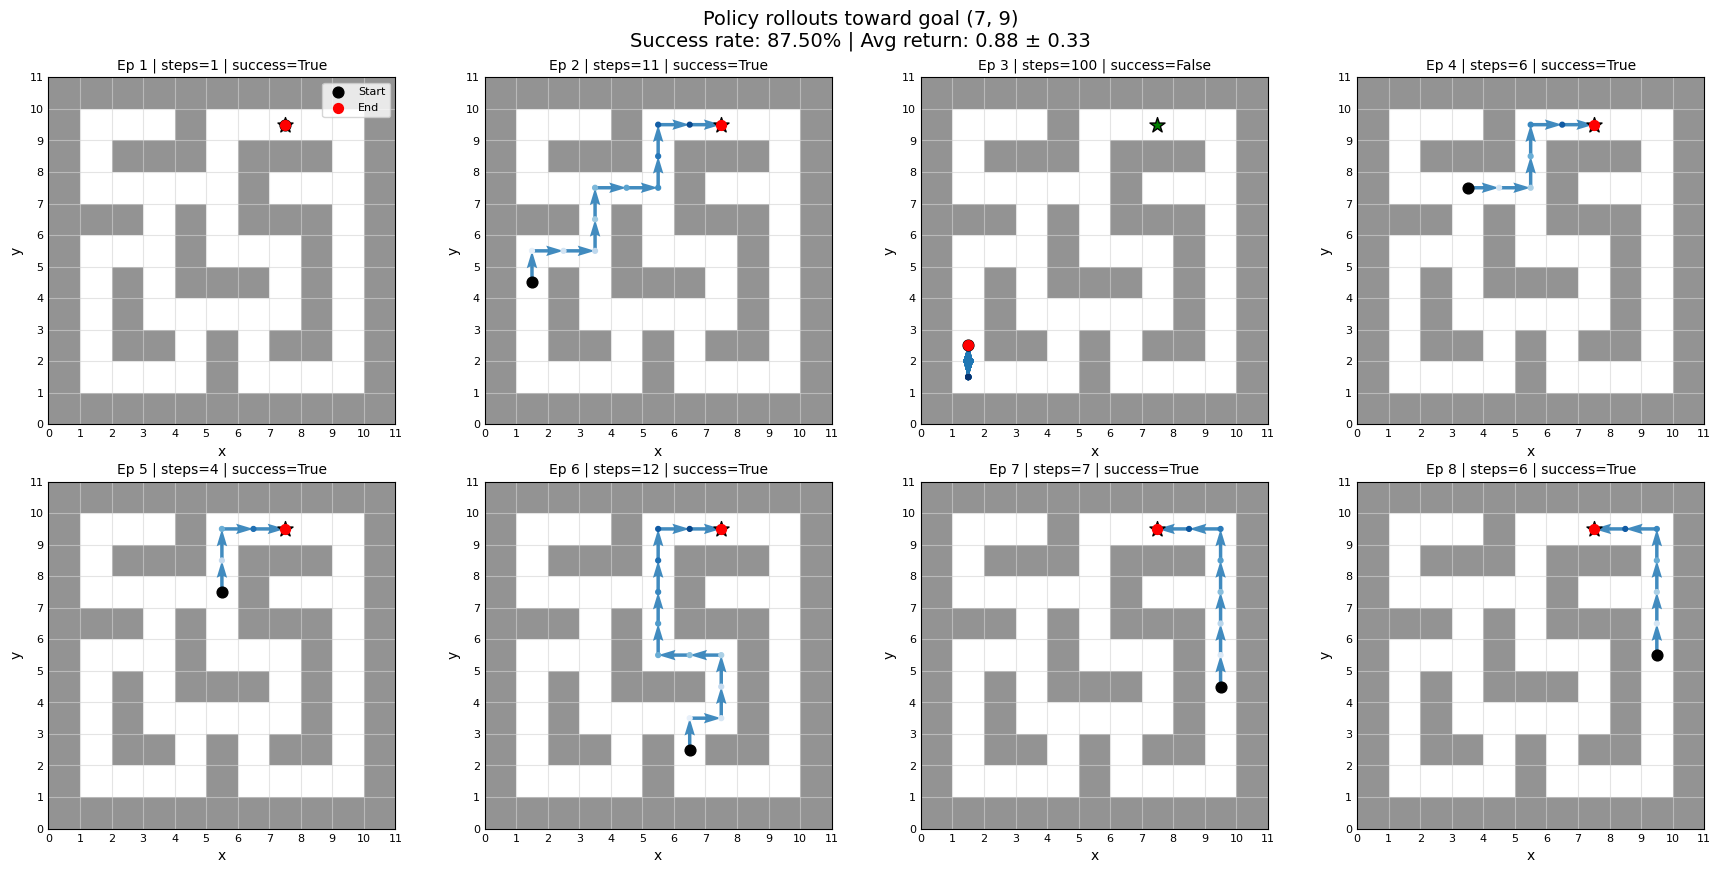

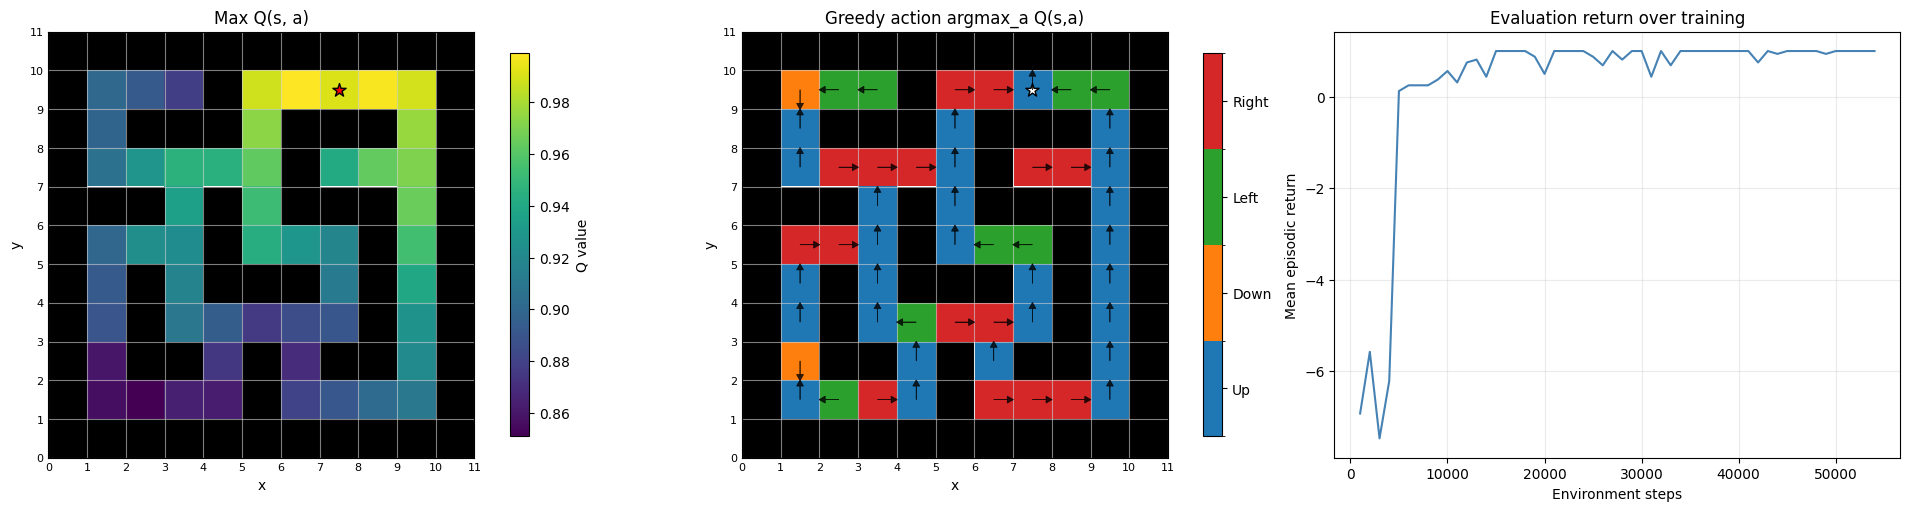

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.748032  4.3738    4.05721   3.998384  3.7924993]
cumulative variance (first 5 dims): [0.10889991 0.20130973 0.28082585 0.35805288 0.4275315 ]
cos(phi(s,a), psi/task): mean=-0.0138, std=0.1005


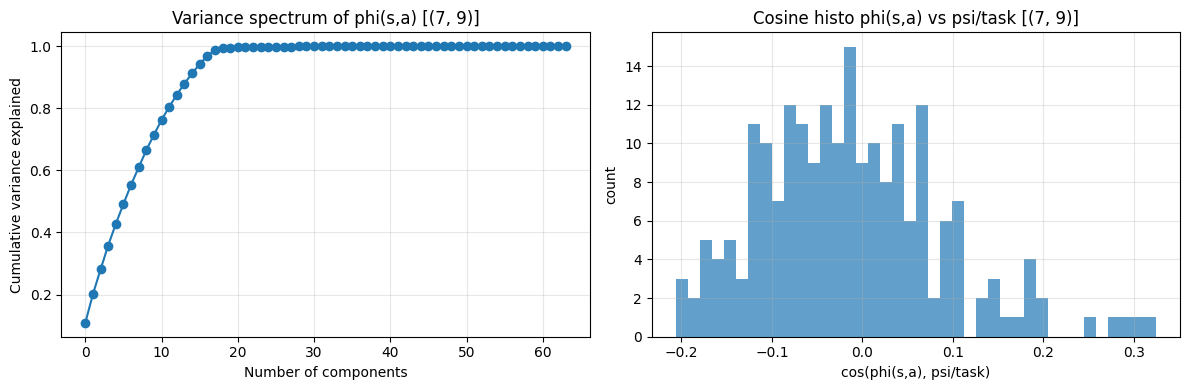


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)     (7, 9)
  (6, 5)      1.000      0.981      0.943      0.913      0.896
  (5, 3)      0.981      1.000      0.989      0.972      0.961
  (3, 3)      0.943      0.989      1.000      0.996      0.990
  (3, 6)      0.913      0.972      0.996      1.000      0.998
  (7, 9)      0.896      0.961      0.990      0.998      1.000

Off-diagonal mean similarity: 0.964
Off-diagonal min similarity: 0.896
Off-diagonal max similarity: 0.998

SEED 999


----- seed 999, goal (6, 5) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-7.437 | eval_len=100.0 | eval_var=18.4486 | ma=-7.438 | best_ma=-7.438 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-8.031 | eval_len=100.0 | eval_var=14.9046 | ma=-7.734 | best_ma=-7.438 | pl

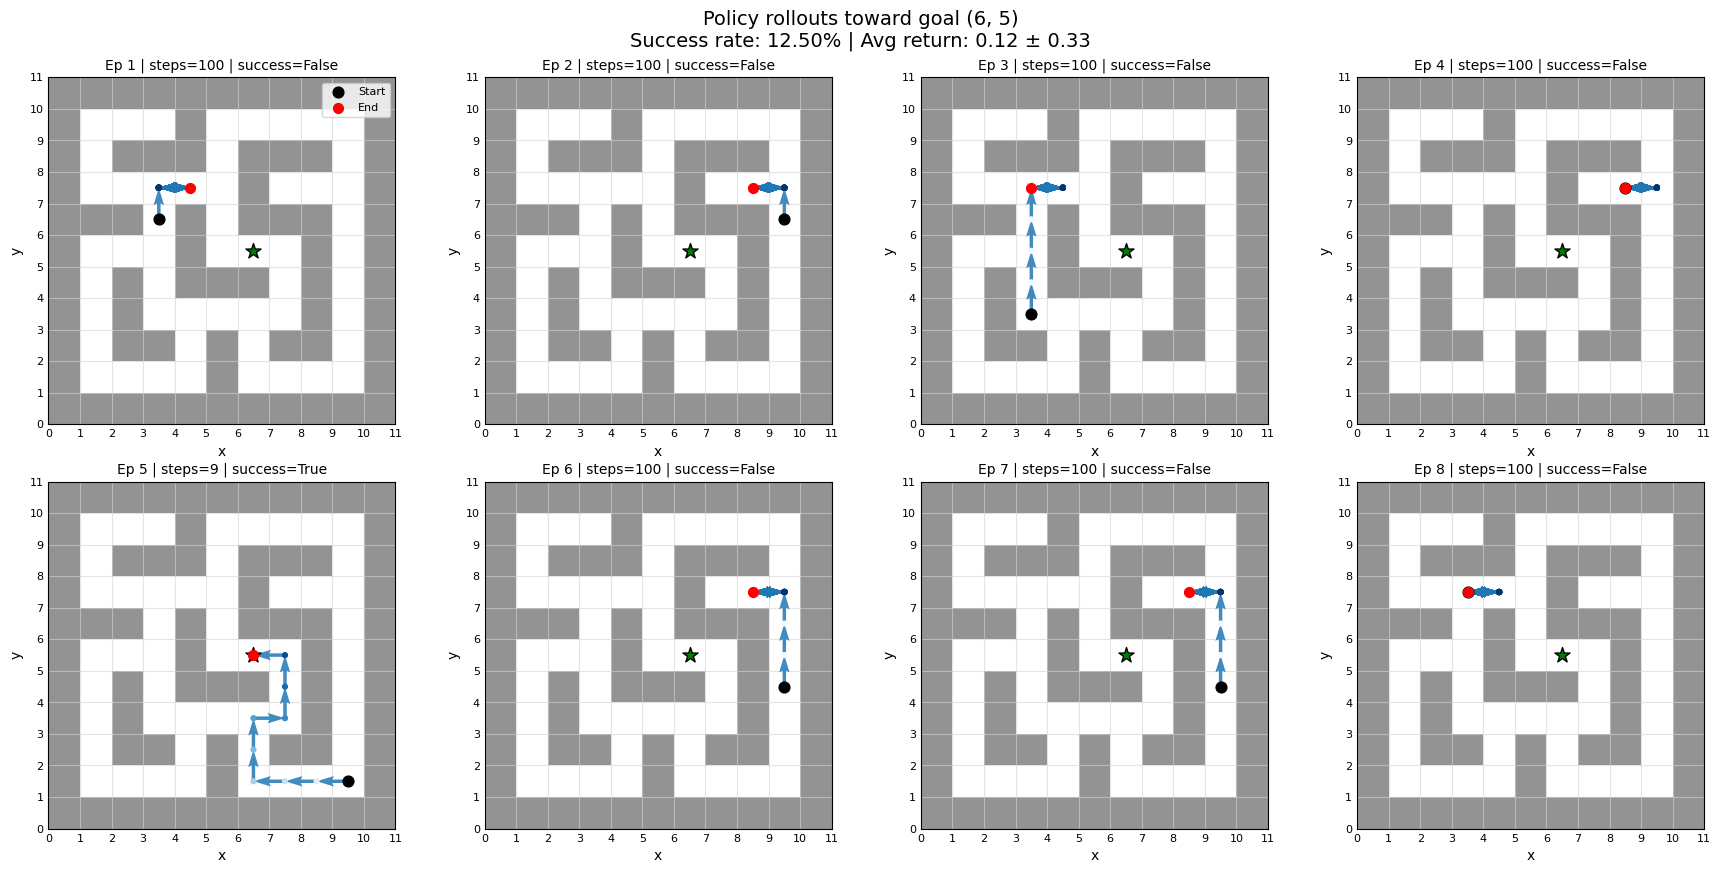

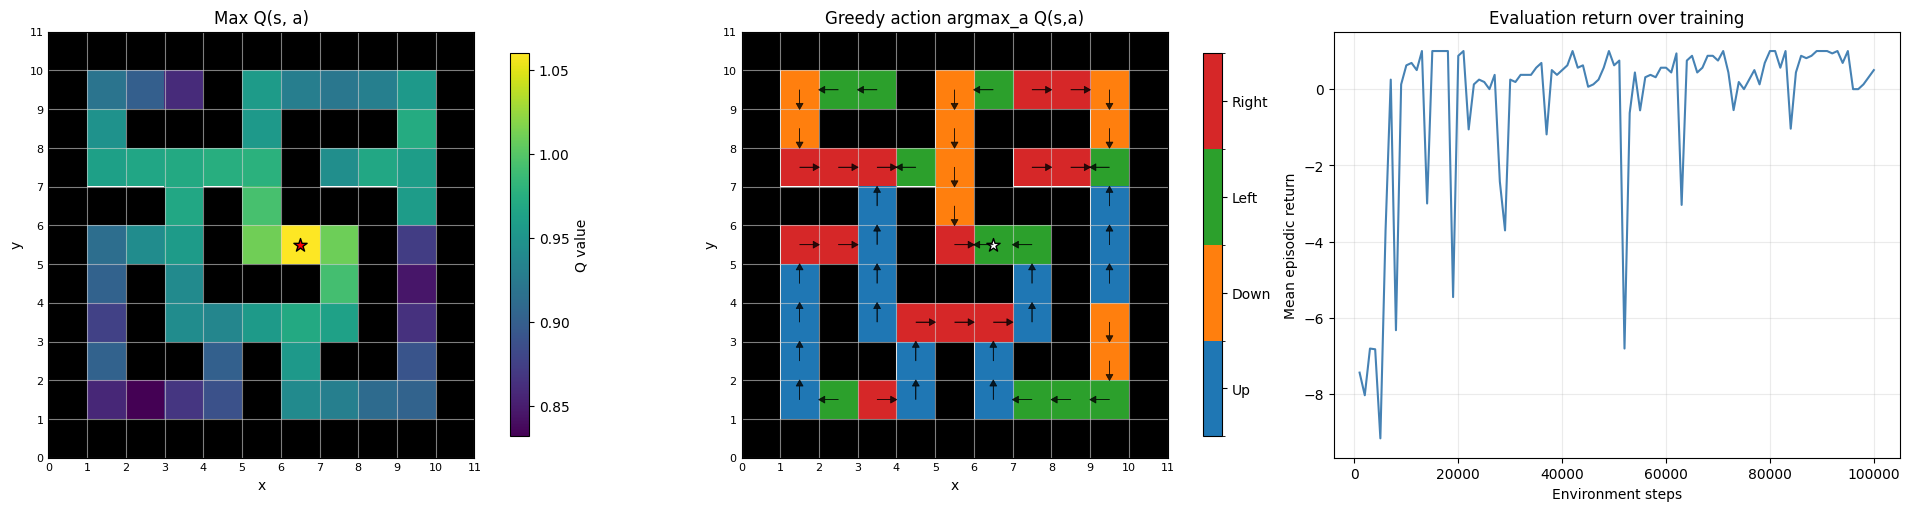

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6026025 4.4011893 4.0415564 3.9851377 3.8908246]
cumulative variance (first 5 dims): [0.10230827 0.1958583  0.2747445  0.35144365 0.4245554 ]
cos(phi(s,a), psi/task): mean=0.0073, std=0.1352


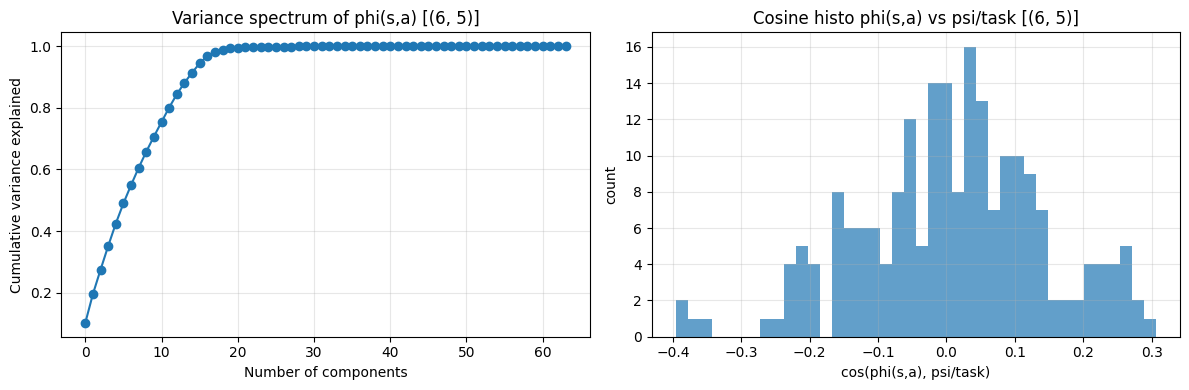


Goal embedding cosine similarity matrix:
     (6, 5)
  (6, 5)      1.000

----- seed 999, goal (5, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.062 | eval_len=93.9 | eval_var=0.0586 | ma=0.062 | best_ma=0.062 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=0.125 | eval_len=87.8 | eval_var=0.1094 | ma=0.094 | best_ma=0.094 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=0.062 | eval_len=93.9 | eval_var=0.0586 | ma=0.083 | best_ma=0.094 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head]

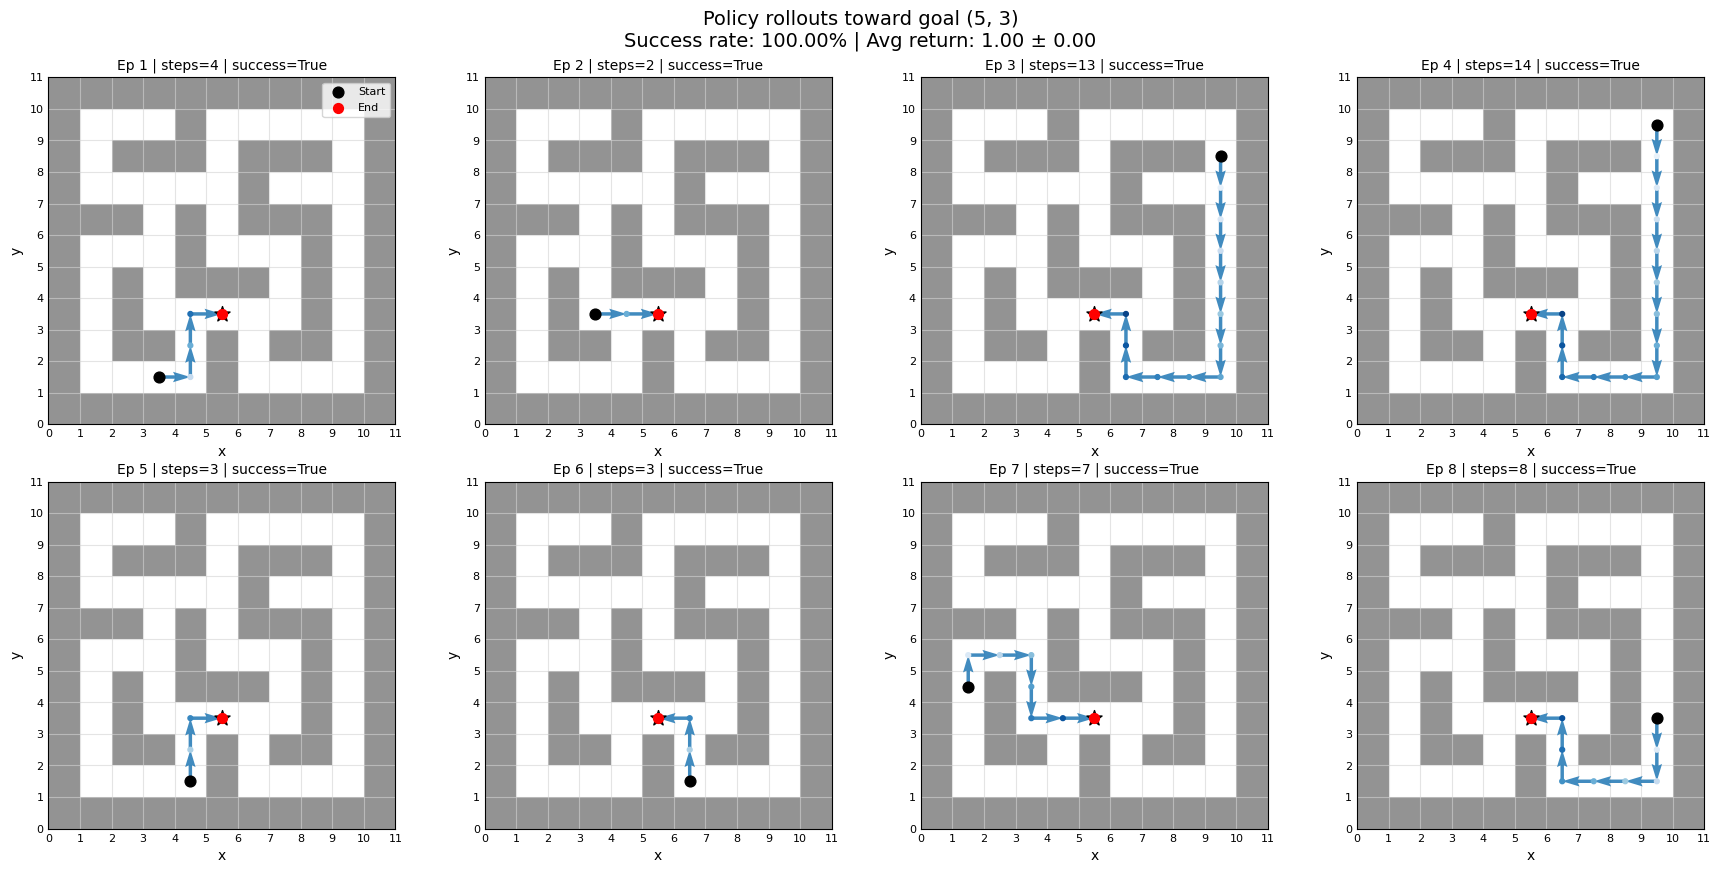

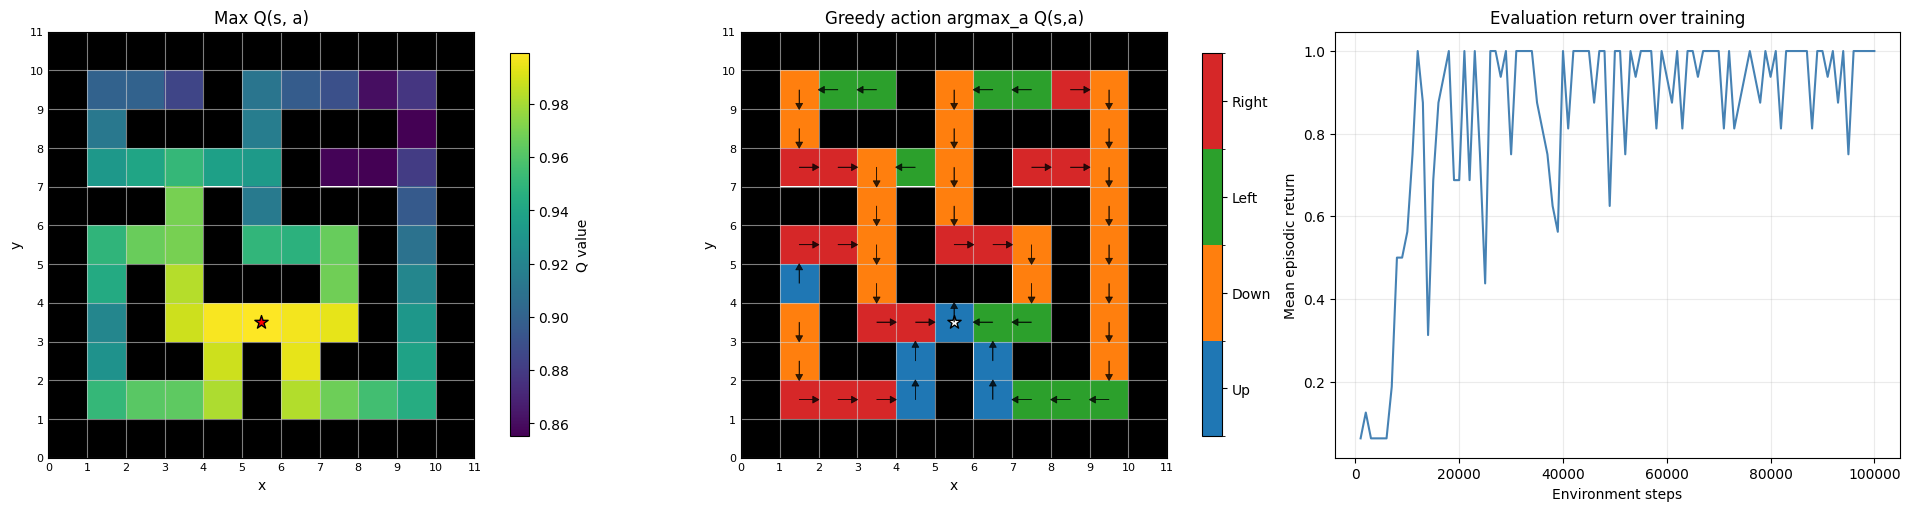

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6026025 4.4011893 4.0415564 3.9851377 3.8908246]
cumulative variance (first 5 dims): [0.10230827 0.1958583  0.2747445  0.35144365 0.4245554 ]
cos(phi(s,a), psi/task): mean=0.0051, std=0.1430


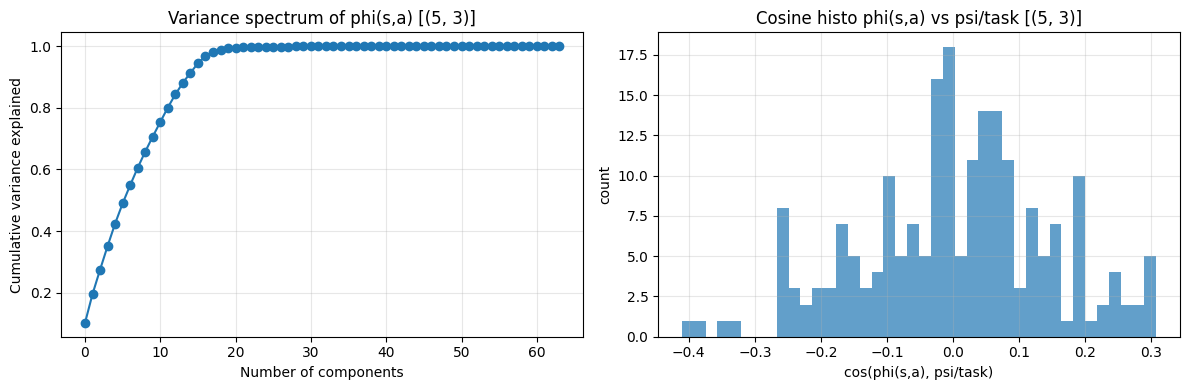


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)
  (6, 5)      1.000      0.969
  (5, 3)      0.969      1.000

Off-diagonal mean similarity: 0.969
Off-diagonal min similarity: 0.969
Off-diagonal max similarity: 0.969

----- seed 999, goal (3, 3) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-6.144 | eval_len=70.8 | eval_var=23.3087 | ma=-6.144 | best_ma=-6.144 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-7.375 | eval_len=82.8 | eval_var=16.3306 | ma=-6.759 | best_ma=-6.144 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-6.800 | eval_len=76.0 | eval_var=20.3925 | ma=-6.773 | best_ma=-6.144 | plateau=2 |

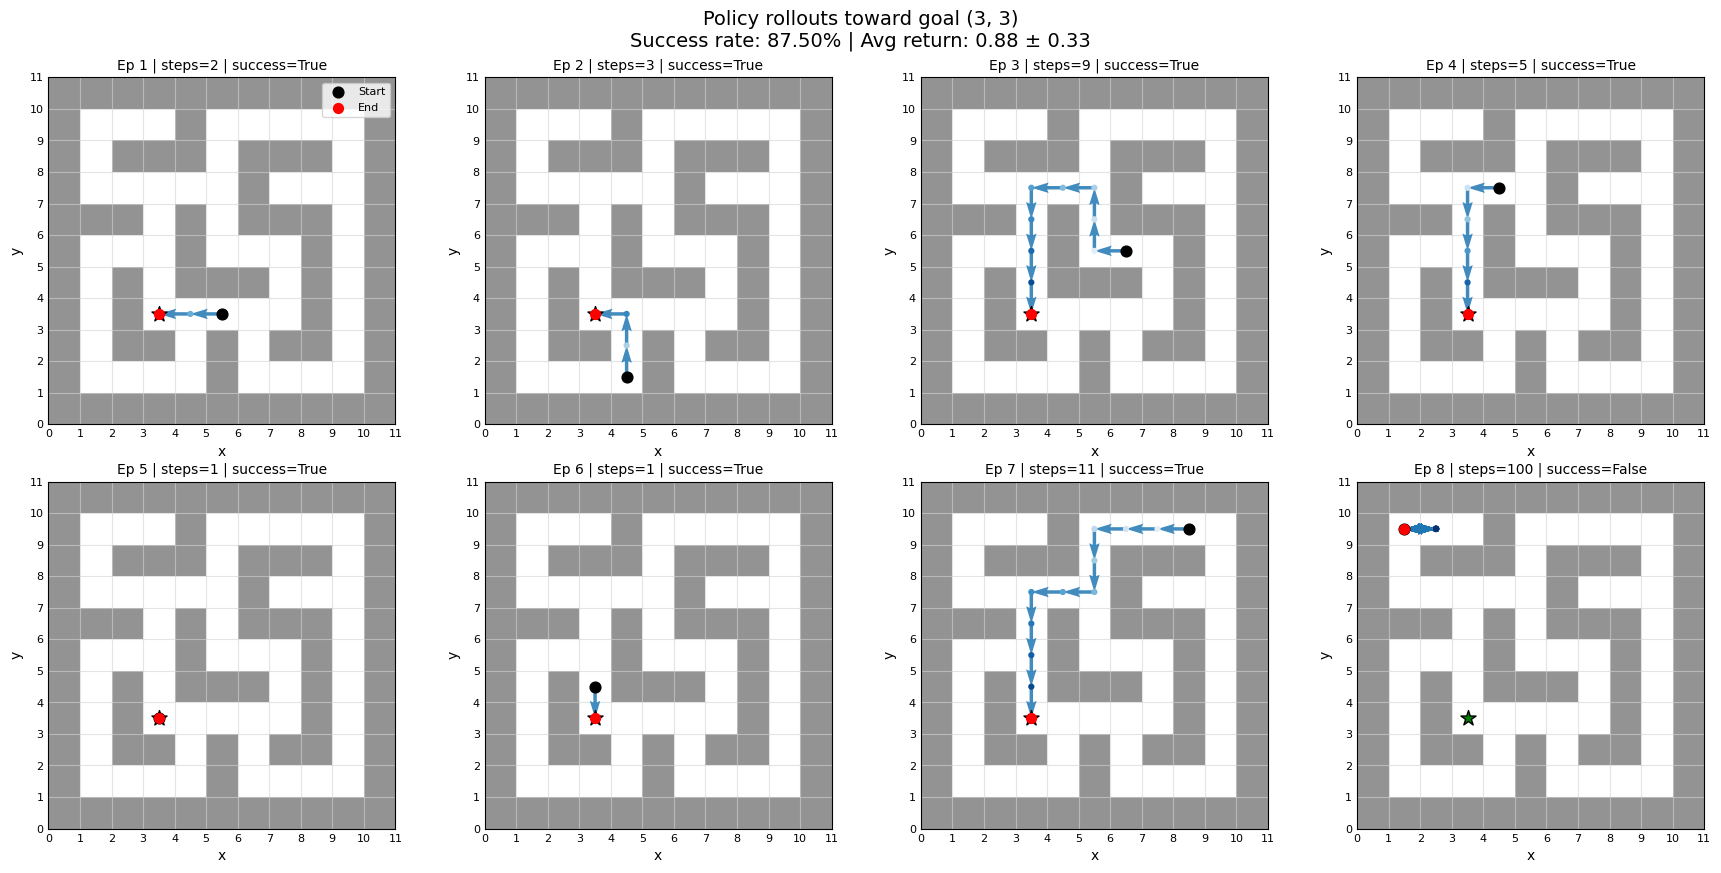

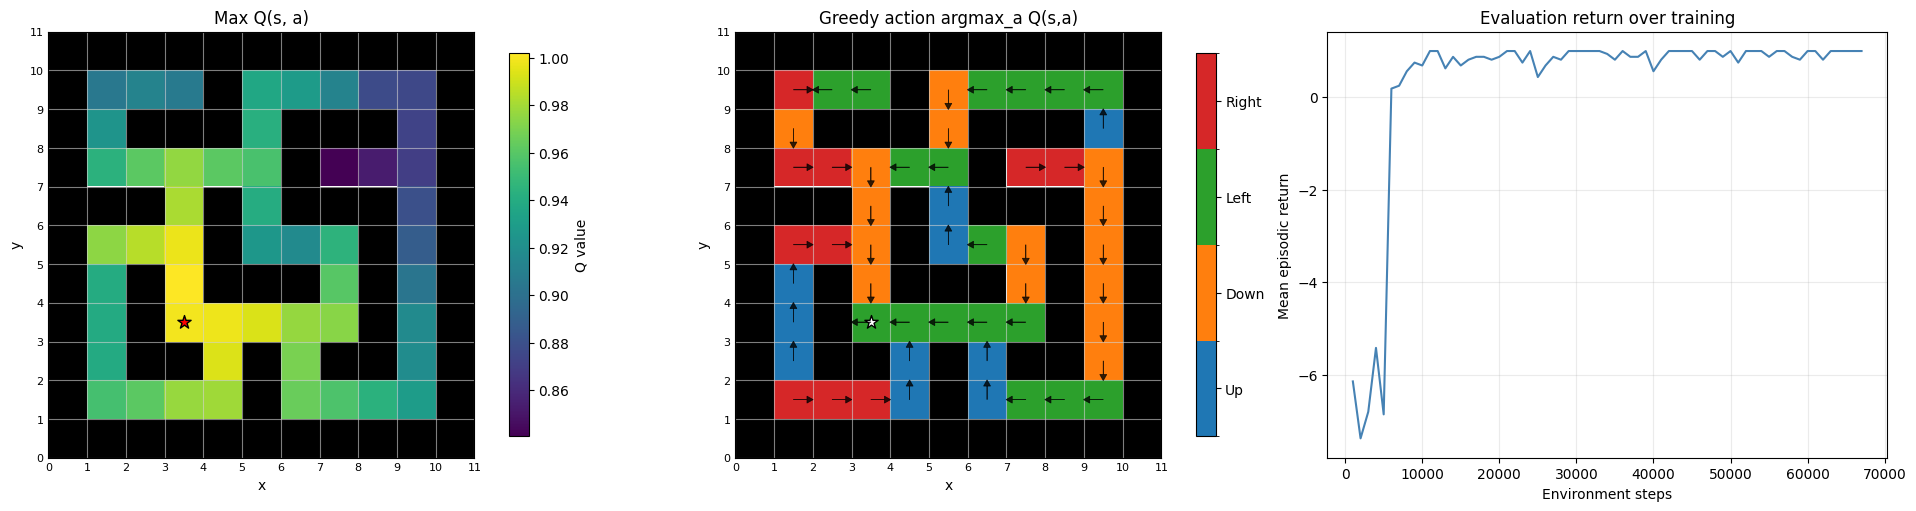

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6026025 4.4011893 4.0415564 3.9851377 3.8908246]
cumulative variance (first 5 dims): [0.10230827 0.1958583  0.2747445  0.35144365 0.4245554 ]
cos(phi(s,a), psi/task): mean=0.0044, std=0.1475


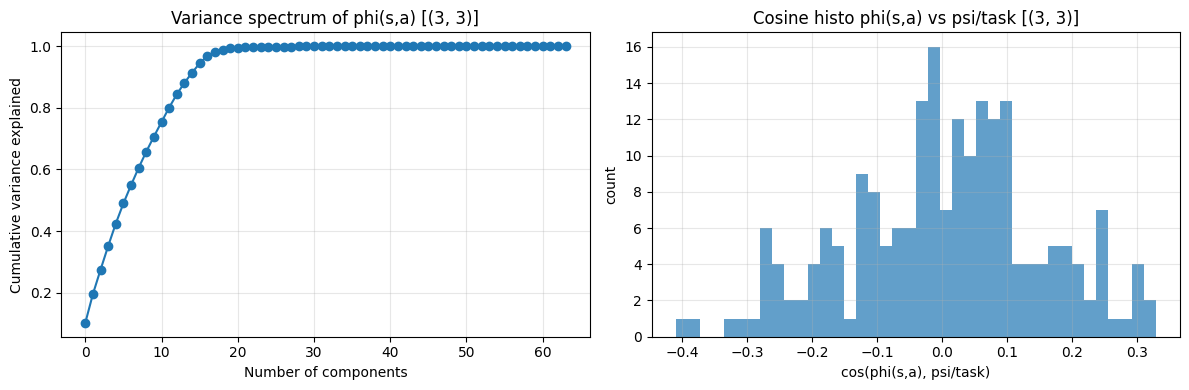


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)
  (6, 5)      1.000      0.969      0.943
  (5, 3)      0.969      1.000      0.995
  (3, 3)      0.943      0.995      1.000

Off-diagonal mean similarity: 0.969
Off-diagonal min similarity: 0.943
Off-diagonal max similarity: 0.995

----- seed 999, goal (3, 6) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-4.081 | eval_len=52.4 | eval_var=25.9553 | ma=-4.081 | best_ma=-4.081 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-4.850 | eval_len=70.9 | eval_var=24.3237 | ma=-4.466 | best_ma=-4.081 | plateau=1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-6.900 | 

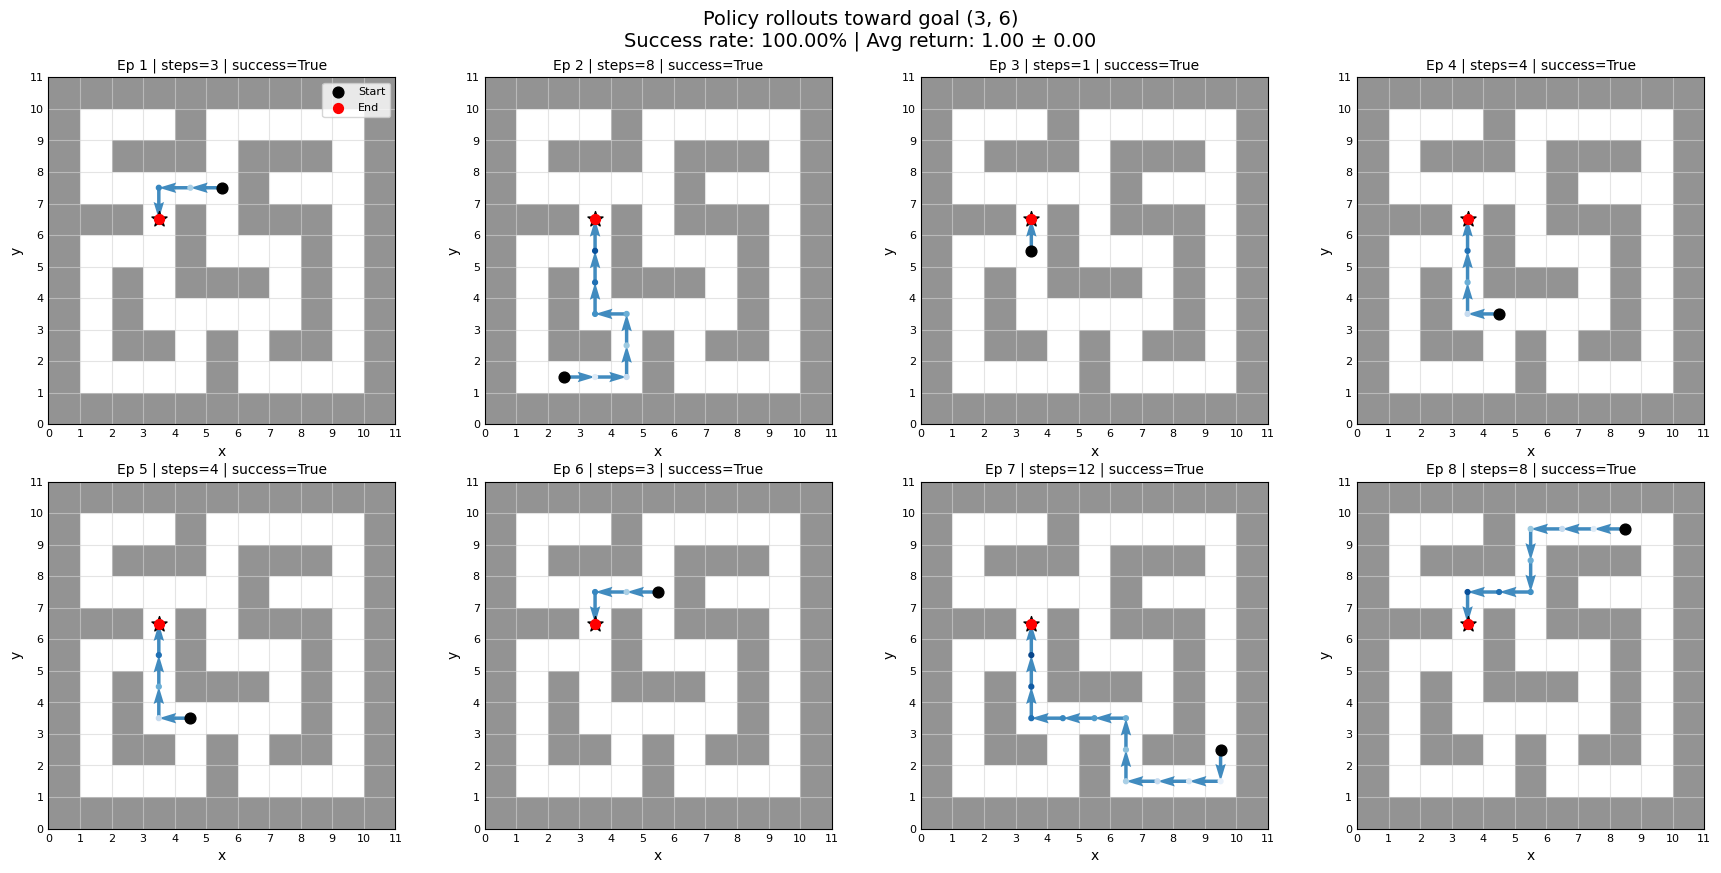

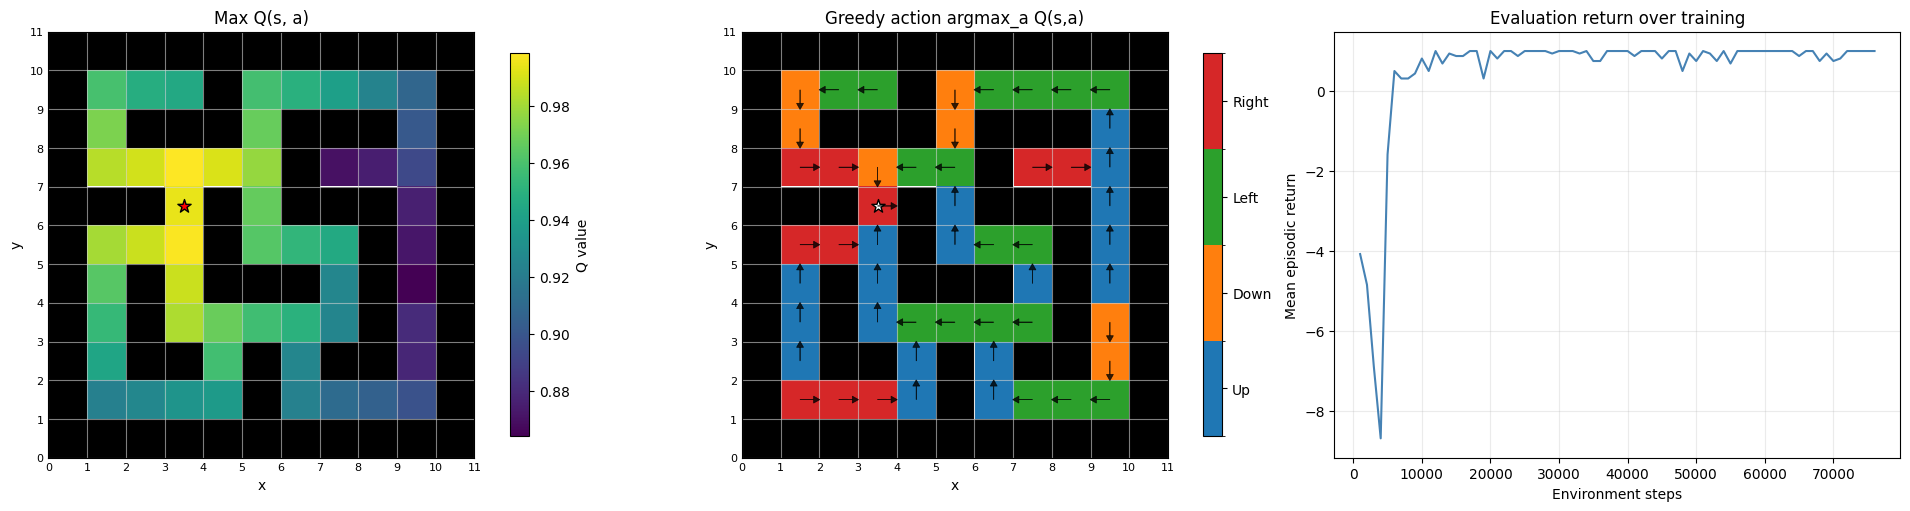

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6026025 4.4011893 4.0415564 3.9851377 3.8908246]
cumulative variance (first 5 dims): [0.10230827 0.1958583  0.2747445  0.35144365 0.4245554 ]
cos(phi(s,a), psi/task): mean=0.0038, std=0.1504


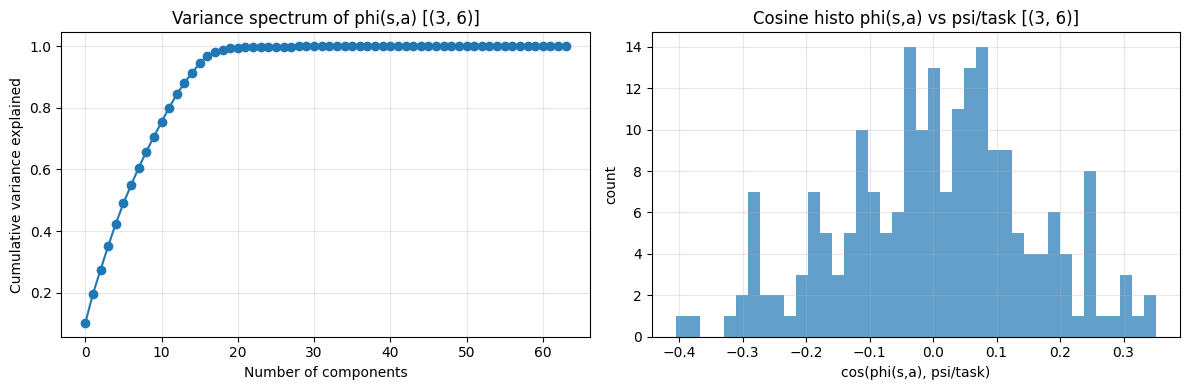


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)
  (6, 5)      1.000      0.969      0.943      0.914
  (5, 3)      0.969      1.000      0.995      0.981
  (3, 3)      0.943      0.995      1.000      0.995
  (3, 6)      0.914      0.981      0.995      1.000

Off-diagonal mean similarity: 0.966
Off-diagonal min similarity: 0.914
Off-diagonal max similarity: 0.995

----- seed 999, goal (7, 9) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-8.131 | eval_len=88.1 | eval_var=11.9759 | ma=-8.131 | best_ma=-8.131 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-7.525 | eval_len=81.9 | eval_var=16.8594 | ma=-7.828 | best_ma=-7.828 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=True | EWC_SA=0

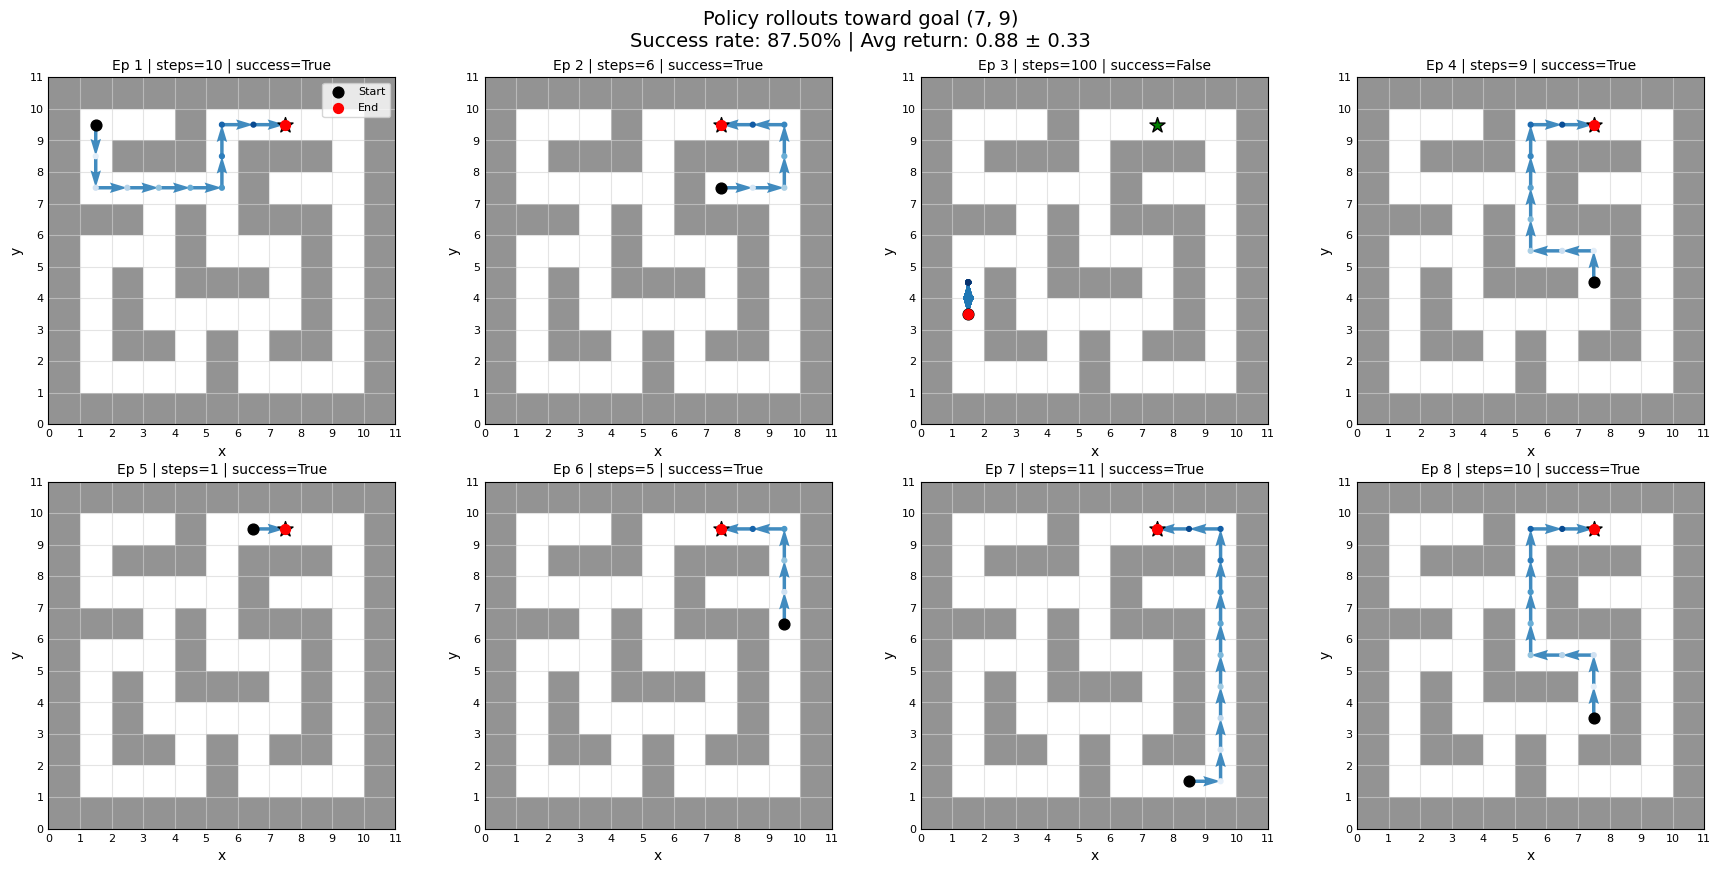

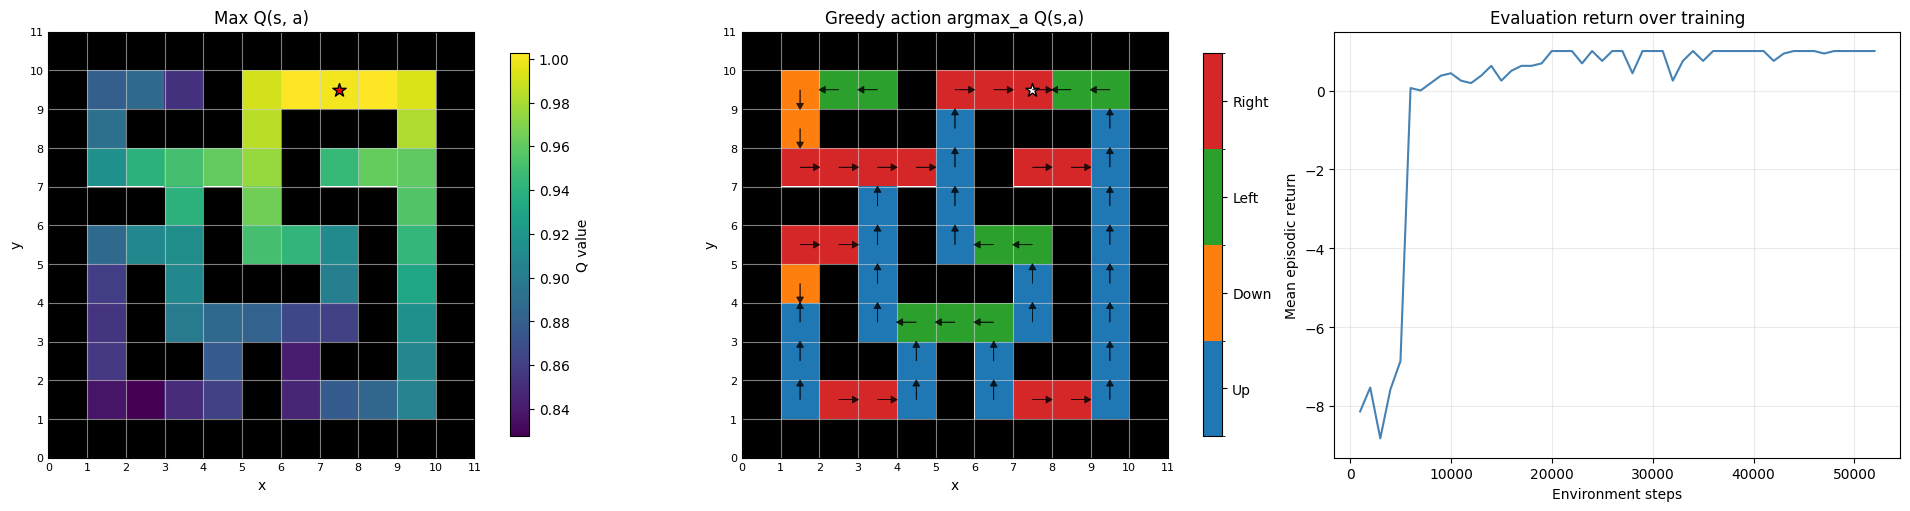

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6026025 4.4011893 4.0415564 3.9851377 3.8908246]
cumulative variance (first 5 dims): [0.10230827 0.1958583  0.2747445  0.35144365 0.4245554 ]
cos(phi(s,a), psi/task): mean=0.0038, std=0.1538


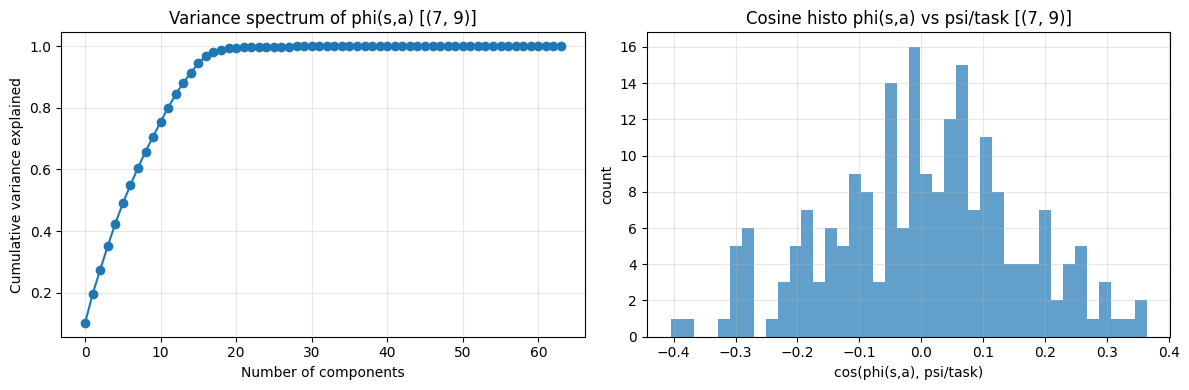


Goal embedding cosine similarity matrix:
     (6, 5)     (5, 3)     (3, 3)     (3, 6)     (7, 9)
  (6, 5)      1.000      0.969      0.943      0.914      0.898
  (5, 3)      0.969      1.000      0.995      0.981      0.970
  (3, 3)      0.943      0.995      1.000      0.995      0.988
  (3, 6)      0.914      0.981      0.995      1.000      0.998
  (7, 9)      0.898      0.970      0.988      0.998      1.000

Off-diagonal mean similarity: 0.965
Off-diagonal min similarity: 0.898
Off-diagonal max similarity: 0.998


In [6]:

SEEDS = [42, 123, 999]
NUM_GOALS = 5

# Use SAME goals across seeds first, so seed averaging is cleaner.
goal_rng = np.random.default_rng(0)
GOALS = sample_goals(NUM_GOALS, goal_rng)
print("Sampled GOALS:", GOALS)

BUFFER_CAPACITY = 100000
LR = float(1e-3)

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder", "q_head"]

# EWC config (same pattern as your notebook)
EWCLAMBDA_SA = 50000.0
EWCLAMBDA_NS = 50000.0
EWC_NUM_BATCHES = 50
EWC_FISHER_ON = "dynamics"   # or "td" if that's what you used before

# ============================================================
# RESULTS CONTAINERS
# ============================================================
overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
    }
    for goal in GOALS
}

seed_artifacts = {}
per_seed_goal_metrics = {}

# ============================================================
# DIMENSIONS / BASE MODELS
# ============================================================
env_tmp = make_env(goal=GOALS[0])
obs_dim = env_tmp.observation_space.shape[0]
num_actions = env_tmp.action_space.n
env_tmp.close()

for seed in SEEDS:
    print(f"\nSEED {seed}\n")
    set_seed(seed)

    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    next_state_encoder = NextStateEncoder(
        obs_dim=obs_dim,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    seed_task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []
    task_replay_memories = {}

    prev_q_net = None
    prev_q_target = None

    ewc_state = EWCState()
    per_seed_goal_metrics[seed] = {}

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed {seed}, goal {goal} -----\n")

        if goal_idx == 0:
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.parameters():
                p.requires_grad = True

            freeze_sa_encoder = False
            epsilon_reduction = False

        else:
            if prev_q_net is None or prev_q_target is None:
                raise ValueError("Previous Q-networks are not available for transfer learning.")

            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)
            q_target.load_state_dict(q_net.state_dict())

            # Your previous transfer setup looked like:
            # freeze phi (sa_encoder), keep psi + q_head trainable
            for p in q_net.sa_encoder.parameters():
                p.requires_grad = False

            for p in q_net.goal_encoder.parameters():
                p.requires_grad = True

            if hasattr(q_net, "q_head"):
                for p in q_net.q_head.parameters():
                    p.requires_grad = True

            freeze_sa_encoder = True
            epsilon_reduction = False

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_before_train_goal",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        use_ewc = goal_idx > 0

        (
            q_network,
            q_target_network,
            next_state_encoder,
            eval_returns,
            eval_returns_time,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_mlp_head_online(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100000,
            warmup_steps=5000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=80000,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=epsilon_reduction,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=20000,
            lr_sa=LR,
            lr_ns=LR,
            lr_td=LR,
            next_state_encoder=next_state_encoder,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=freeze_sa_encoder,
            ewc_state=ewc_state,
            ewc_lambda_sa=EWCLAMBDA_SA if use_ewc else 0.0,
            ewc_lambda_ns=EWCLAMBDA_NS if use_ewc else 0.0,
            enable_early_stop=True,
        )

        task_replay_memories[goal] = buffer

        (
            ref_params_sa,
            fisher_sa,
            ref_params_ns,
            fisher_ns,
        ) = compute_ewc_fisher_for_task(
            q_network=q_network,
            next_state_encoder=next_state_encoder,
            replay_buffer=buffer,
            goal=goal,
            num_actions=num_actions,
            device=DEVICE,
            num_batches=EWC_NUM_BATCHES,
            batch_size=256,
            gamma=0.99,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            fisher_on=EWC_FISHER_ON,
        )

        ewc_state.ref_params_sa = ref_params_sa
        ewc_state.fisher_sa = fisher_sa
        ewc_state.ref_params_ns = ref_params_ns
        ewc_state.fisher_ns = fisher_ns

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_after_train_goal",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        before_snap = weight_history[-2]
        after_snap = weight_history[-1]

        sa_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="sa",
        )

        goal_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="goal",
        )

        print(
            f"SA drift goal {goal} "
            f"L2 {sa_change_stats['sample_l2']:.6f} "
            f"L1 {sa_change_stats['sample_l1']:.6f} "
            f"Linf {sa_change_stats['sample_linf']:.6f} "
            f"mean {sa_change_stats['sample_mean_abs']:.6e} "
            f"rms {sa_change_stats['sample_rms']:.6e} "
            f"meanΔ {sa_change_stats['stats_delta']['delta_mean']:.6e} "
            f"stdΔ {sa_change_stats['stats_delta']['delta_std']:.6e} "
            f"p50Δ {sa_change_stats['stats_delta']['delta_p50']:.6e}"
        )

        print(
            f"Goal drift goal {goal} "
            f"L2 {goal_change_stats['sample_l2']:.6f} "
            f"L1 {goal_change_stats['sample_l1']:.6f} "
            f"Linf {goal_change_stats['sample_linf']:.6f} "
            f"mean {goal_change_stats['sample_mean_abs']:.6e} "
            f"rms {goal_change_stats['sample_rms']:.6e} "
            f"meanΔ {goal_change_stats['stats_delta']['delta_mean']:.6e} "
            f"stdΔ {goal_change_stats['stats_delta']['delta_std']:.6e} "
            f"p50Δ {goal_change_stats['stats_delta']['delta_p50']:.6e}"
        )

        visualise_q_table(
            goal=goal,
            q_network=q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_network,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(
            seed_task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        per_seed_goal_metrics[seed][goal] = {
            "goal_idx": goal_idx,
            "eval_returns": eval_returns,
            "eval_returns_time": eval_returns_time,
            "min_steps": min_steps,
            "min_time": min_time,
        }

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)
        overall_results[goal]["sa_weight_change"].append(sa_change_stats)
        overall_results[goal]["goal_weight_change"].append(goal_change_stats)

    seed_artifacts[seed] = {
        "goals": list(GOALS),
        "final_q_net": deepcopy(prev_q_net),
        "final_q_target": deepcopy(prev_q_target),
        "final_next_state_encoder": deepcopy(next_state_encoder),
        "task_replay_memories": deepcopy(task_replay_memories),
        "task_embeddings": deepcopy(seed_task_embedding_memory),
        "weight_history": deepcopy(weight_history),
    }

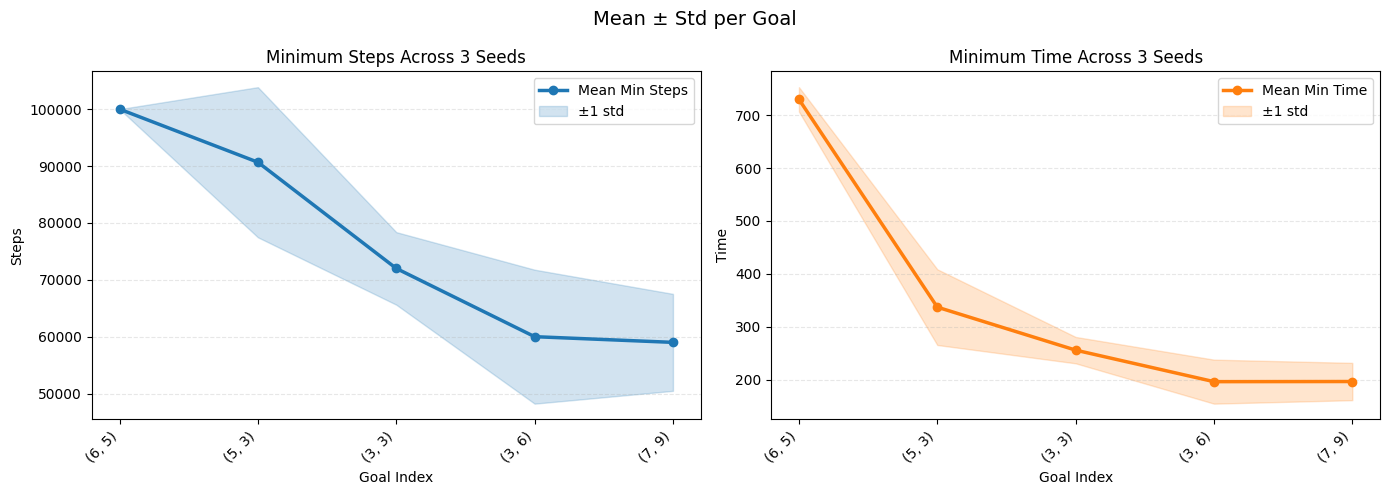

In [7]:
plot_min_steps_and_min_time(
    overall_results=overall_results,
    seeds=SEEDS,
)

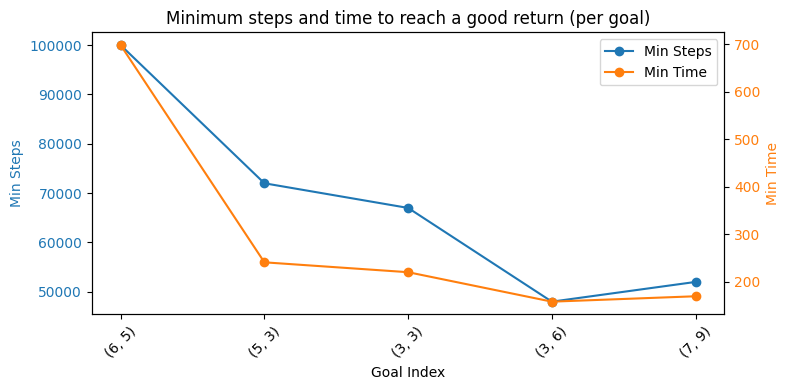

In [8]:
goals = list(overall_results.keys())

min_steps_per_goal = []
min_time_per_goal = []
used_goals = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.array(steps_raw).flatten()
    time_arr  = np.array(time_raw).flatten()

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    steps_arr = np.array([np.nan if x is None else x for x in steps_arr], dtype=float)
    time_arr  = np.array([np.nan if x is None else x for x in time_arr], dtype=float)

    if np.all(np.isnan(steps_arr)) or np.all(np.isnan(time_arr)):
        print(f"[WARN] Skipping goal {goal}: no valid results")
        continue


    min_steps_per_goal.append(steps_arr.min())
    min_time_per_goal.append(time_arr.min())
    used_goals.append(goal)

if not min_steps_per_goal:
    raise ValueError("No goals with non-empty min_steps/min_time found.")

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
line1 = ax1.plot(
    x, min_steps_per_goal,
    label="Min Steps",
    color="tab:blue",
    marker="o",
)
ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
line2 = ax2.plot(
    x, min_time_per_goal,
    label="Min Time",
    color="tab:orange",
    marker="o",
)
ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
plt.show()

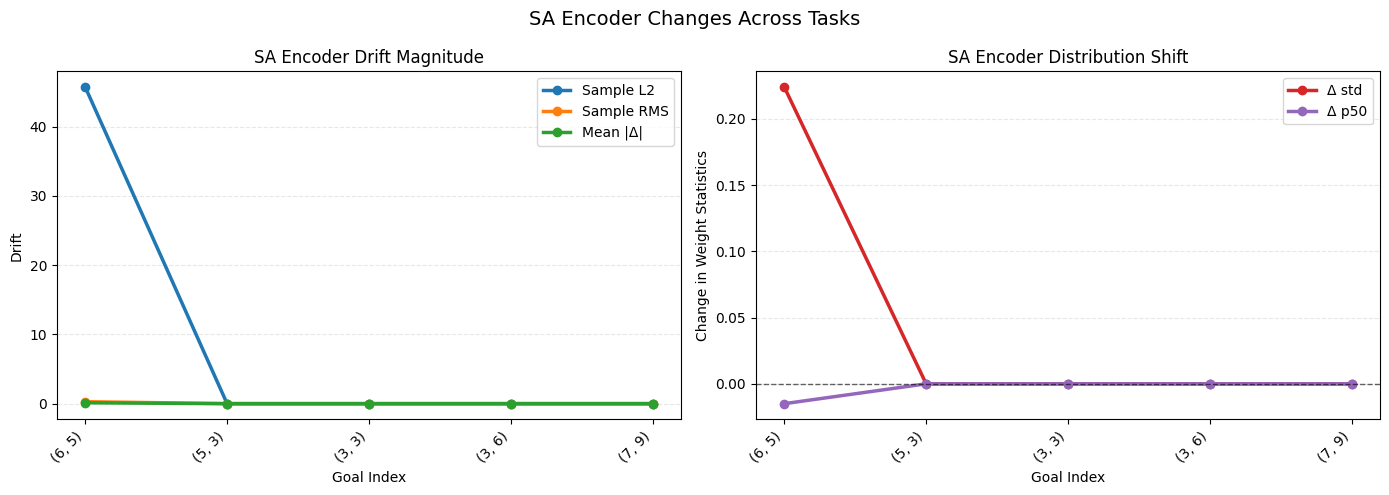

In [9]:
plot_sa_encoder_changes_across_tasks(overall_results)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [10]:
# =========================================================
# Backward-task fine-tuning from final model
# New cell
# =========================================================

BACKWARD_GOALS_MODE = "early"   # "early" or "all"
FT_MAX_GOALS = 3
FT_TOTAL_STEPS = 20000
FT_WARMUP_STEPS = 2000
FT_LR = 1e-4

fine_tune_results = {
    "full": {},
    "freeze_phi": {},
    "freeze_psi_like": {},
}

def set_requires_grad_by_prefix(model, prefixes_to_freeze):
    for name, p in model.named_parameters():
        p.requires_grad = True
        for prefix in prefixes_to_freeze:
            if name.startswith(prefix):
                p.requires_grad = False

for seed in SEEDS:
    print(f"\n========== Backward fine-tuning seed={seed} ==========\n")

    seed_goals = seed_artifacts[seed]["goals"]
    final_q_net = seed_artifacts[seed]["final_q_net"]
    final_q_target = seed_artifacts[seed]["final_q_target"]
    final_next_state_encoder = seed_artifacts[seed]["final_next_state_encoder"]

    if BACKWARD_GOALS_MODE == "early":
        backward_goals = seed_goals[:FT_MAX_GOALS]
    elif BACKWARD_GOALS_MODE == "all":
        backward_goals = seed_goals[:-1]
    else:
        raise ValueError("BACKWARD_GOALS_MODE must be 'early' or 'all'")

    for regime_name in fine_tune_results.keys():
        fine_tune_results[regime_name].setdefault(seed, {})

    for goal in backward_goals:
        print(f"\n[seed={seed}] backward goal={goal}\n")

        # ---------------------------
        # Regime 1: full fine-tune
        # ---------------------------
        q_net_full = deepcopy(final_q_net)
        q_target_full = deepcopy(final_q_target)
        ns_full = deepcopy(final_next_state_encoder)

        (
            q_network_ft,
            q_target_network_ft,
            next_state_encoder_ft,
            eval_returns_ft,
            eval_returns_time_ft,
            min_steps_ft,
            min_time_ft,
            task_embedding_ft,
            sa_embedding_mean_ft,
            sa_embedding_fixed_ft,
            sa_batch_final_ft,
            buffer_ft,
        ) = dqn_train_mlp_head_online(
            seed=seed,
            q_network=q_net_full,
            q_target_network=q_target_full,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=FT_TOTAL_STEPS,
            warmup_steps=FT_WARMUP_STEPS,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=0.2,
            eps_end=0.05,
            eps_decay_steps=FT_TOTAL_STEPS,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=False,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=FT_TOTAL_STEPS,
            lr_sa=FT_LR,
            lr_ns=FT_LR,
            lr_td=FT_LR,
            next_state_encoder=ns_full,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=False,
            ewc_state=None,
            ewc_lambda_sa=0.0,
            ewc_lambda_ns=0.0,
            enable_early_stop=True,
        )

        fine_tune_results["full"][seed][goal] = {
            "eval_returns": eval_returns_ft,
            "eval_returns_time": eval_returns_time_ft,
            "min_steps": min_steps_ft,
            "min_time": min_time_ft,
            "baseline_min_steps": per_seed_goal_metrics[seed][goal]["min_steps"],
            "baseline_min_time": per_seed_goal_metrics[seed][goal]["min_time"],
        }

        # ---------------------------
        # Regime 2: freeze phi (sa_encoder)
        # ---------------------------
        q_net_phi = deepcopy(final_q_net)
        q_target_phi = deepcopy(final_q_target)
        ns_phi = deepcopy(final_next_state_encoder)

        (
            q_network_ft,
            q_target_network_ft,
            next_state_encoder_ft,
            eval_returns_ft,
            eval_returns_time_ft,
            min_steps_ft,
            min_time_ft,
            task_embedding_ft,
            sa_embedding_mean_ft,
            sa_embedding_fixed_ft,
            sa_batch_final_ft,
            buffer_ft,
        ) = dqn_train_mlp_head_online(
            seed=seed,
            q_network=q_net_phi,
            q_target_network=q_target_phi,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=FT_TOTAL_STEPS,
            warmup_steps=FT_WARMUP_STEPS,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=0.2,
            eps_end=0.05,
            eps_decay_steps=FT_TOTAL_STEPS,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=False,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=FT_TOTAL_STEPS,
            lr_sa=FT_LR,
            lr_ns=FT_LR,
            lr_td=FT_LR,
            next_state_encoder=ns_phi,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=True,
            ewc_state=None,
            ewc_lambda_sa=0.0,
            ewc_lambda_ns=0.0,
            enable_early_stop=True,
        )

        fine_tune_results["freeze_phi"][seed][goal] = {
            "eval_returns": eval_returns_ft,
            "eval_returns_time": eval_returns_time_ft,
            "min_steps": min_steps_ft,
            "min_time": min_time_ft,
            "baseline_min_steps": per_seed_goal_metrics[seed][goal]["min_steps"],
            "baseline_min_time": per_seed_goal_metrics[seed][goal]["min_time"],
        }

        # ---------------------------
        # Regime 3: freeze psi-like side
        # Practical approximation for current trainer:
        # freeze goal_encoder + q_head manually, leave sa side trainable
        # ---------------------------
        q_net_psi = deepcopy(final_q_net)
        q_target_psi = deepcopy(final_q_target)
        ns_psi = deepcopy(final_next_state_encoder)

        set_requires_grad_by_prefix(q_net_psi, prefixes_to_freeze=["goal_encoder", "q_head"])
        set_requires_grad_by_prefix(q_target_psi, prefixes_to_freeze=["goal_encoder", "q_head"])

        # trainer may reset some flags internally, so re-apply before call if needed
        for name, p in q_net_psi.named_parameters():
            if name.startswith("goal_encoder") or name.startswith("q_head"):
                p.requires_grad = False

        (
            q_network_ft,
            q_target_network_ft,
            next_state_encoder_ft,
            eval_returns_ft,
            eval_returns_time_ft,
            min_steps_ft,
            min_time_ft,
            task_embedding_ft,
            sa_embedding_mean_ft,
            sa_embedding_fixed_ft,
            sa_batch_final_ft,
            buffer_ft,
        ) = dqn_train_mlp_head_online(
            seed=seed,
            q_network=q_net_psi,
            q_target_network=q_target_psi,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=FT_TOTAL_STEPS,
            warmup_steps=FT_WARMUP_STEPS,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=0.2,
            eps_end=0.05,
            eps_decay_steps=FT_TOTAL_STEPS,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=False,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=FT_TOTAL_STEPS,
            lr_sa=FT_LR,
            lr_ns=FT_LR,
            lr_td=FT_LR,
            next_state_encoder=ns_psi,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=False,
            ewc_state=None,
            ewc_lambda_sa=0.0,
            ewc_lambda_ns=0.0,
            enable_early_stop=True,
        )

        fine_tune_results["freeze_psi_like"][seed][goal] = {
            "eval_returns": eval_returns_ft,
            "eval_returns_time": eval_returns_time_ft,
            "min_steps": min_steps_ft,
            "min_time": min_time_ft,
            "baseline_min_steps": per_seed_goal_metrics[seed][goal]["min_steps"],
            "baseline_min_time": per_seed_goal_metrics[seed][goal]["min_time"],
        }

# quick printout
for regime_name, seed_data in fine_tune_results.items():
    print(f"\n========== {regime_name} ==========\n")
    for seed, goal_data in seed_data.items():
        for goal, vals in goal_data.items():
            base_steps = vals["baseline_min_steps"]
            ft_steps = vals["min_steps"]
            ratio = None
            if base_steps is not None and ft_steps is not None and base_steps != 0:
                ratio = ft_steps / base_steps

            print(
                f"seed={seed}, goal={goal}, "
                f"baseline_steps={base_steps}, "
                f"ft_steps={ft_steps}, "
                f"relearn_ratio={ratio}"
            )


========== Backward fine-tuning seed=42 ==========


[seed=42] backward goal=(6, 5)

[DQN-MLP-head] step=   1000 | eps=0.193 | eval_return=-8.387 | eval_len=93.9 | eval_var=5.9023 | ma=-8.387 | best_ma=-8.387 | plateau=0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   2000 | eps=0.185 | eval_return=-7.156 | eval_len=87.7 | eval_var=14.3662 | ma=-7.772 | best_ma=-7.772 | plateau=0 | TD=0.0091 | Contrastive=4.5427 | DynTotal=4.5526 | diag=0.9234 | offdiag=0.6869 | SigReg=0.9917 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   3000 | eps=0.178 | eval_return=0.062 | eval_len=93.9 | eval_var=0.0586 | ma=-5.160 | best_ma=-5.160 | plateau=0 | TD=0.0004 | Contrastive=3.8124 | DynTotal=3.8223 | diag=0.7571 | offdiag=0.2332 | SigReg=0.9842 | freeze_sa=False | EWC_SA=0.0000000000 | EWC_NS=0.0000000000
[DQN-MLP-head] step=   400

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
# =========================================================
# Convert backward fine-tuning results to plot_min_steps_and_min_time format
# =========================================================

def build_plot_results_from_finetune(fine_tune_results, regime_name):
    plot_results = {}

    for seed, goal_dict in fine_tune_results[regime_name].items():
        for goal, vals in goal_dict.items():
            if goal not in plot_results:
                plot_results[goal] = {
                    "min_steps": [],
                    "min_time": [],
                }

            plot_results[goal]["min_steps"].append(vals["min_steps"])
            plot_results[goal]["min_time"].append(vals["min_time"])

    return plot_results

ft_plot_results_full = build_plot_results_from_finetune(fine_tune_results, "full")
ft_plot_results_freeze_phi = build_plot_results_from_finetune(fine_tune_results, "freeze_phi")
ft_plot_results_freeze_psi = build_plot_results_from_finetune(fine_tune_results, "freeze_psi_like")

plot_min_steps_and_min_time(
    overall_results=ft_plot_results_full,
    seeds=SEEDS,
)

plot_min_steps_and_min_time(
    overall_results=ft_plot_results_freeze_phi,
    seeds=SEEDS,
)

plot_min_steps_and_min_time(
    overall_results=ft_plot_results_freeze_psi,
    seeds=SEEDS,
)

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_2d_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])